numpy matplotlib openpyxl pandas scipy intertools

### Важно!!!
В коде присутствуют формулы с надписью "Убрать потом формулу ниже и вернуть эту"
Формулы под этими формулами - лишь мое предположение, которое может быть ложным

In [1]:
import math
import openpyxl
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import pandas as pd
from IPython.display import display
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image
from pathlib import Path

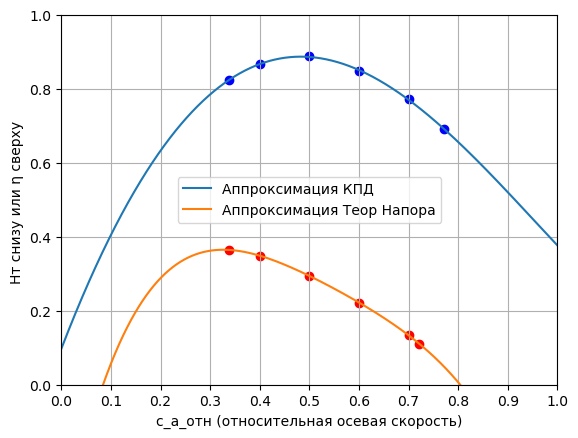

In [2]:
# График с учебника рис. 4

# Точки
x_η_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])       # точки по оси X для теоретического напора
η_dots = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])      # точки по оси Y для теоретического напора

x_Hт_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])    # точки по оси X для КПД
Hт_dots = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721]) # точки по оси Y для КПД

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(x_Hт_dots, Hт_dots, stepen)
poly = np.poly1d(coeffs)
coeffs1 = np.polyfit(x_η_dots, η_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000     # Число точек
x_Hт_dots_smooth = np.linspace(0, 1, smoothness)
Hт_dots_smooth = poly(x_Hт_dots_smooth)
x_η_dots_smooth = np.linspace(0, 1, smoothness)
η_dots_smooth = poly1(x_η_dots_smooth)

plt.plot(x_η_dots_smooth, η_dots_smooth, label="Аппроксимация КПД")
plt.plot(x_Hт_dots_smooth, Hт_dots_smooth, label="Аппроксимация Теор Напора")
plt.scatter(x_Hт_dots, Hт_dots, color="red")
plt.scatter(x_η_dots, η_dots, color="blue")
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.xlabel("c_a_отн (относительная осевая скорость)")
plt.ylabel("Hт снизу или η сверху ")
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()
plt.close()

Hт_x_line = x_Hт_dots_smooth    # Координаты X для линии теоретического напора
Hт_y_line = Hт_dots_smooth      # Координаты Y для линии теоретического напора
η_x_line = x_η_dots_smooth      # Координаты X для линии КПД
η_y_line = η_dots_smooth        # Координаты Y для линии КПД


In [3]:
Tа_полн = 288   # K
Pа_полн = 1.013 * 10**5  # Па
G_в = 58.7  # кг/с
π_к_полн = 18.2  # Степень повышения давления в компрессоре
n = 8600  # об/мин
n_ob_min = n

R_в = 287.4  # Дж/(кг*К)
k = 1.4  # показатель адиабаты для воздуха
# Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха

In [4]:
n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
print(f" n = {n}")

 n = 900.589894029074


# 2. Выбор основных параметров компрессора и предварительный расчет проточной части по средней линии тока

## Предварительный расчет проточной части по средней линии тока

Исходя из расчета полученного из файла results_compressor_search.xlsx подставляем значения для выбранного варианта

In [5]:
η_к_полн = 0.84649
d1_отн = 0.43
c_а1_отн = 0.65
c_a2_отн = 0.36
Hт_ср_отн = 0.3
H_т1 = 0.25
R_ср1 = 0.5
D_type = 'D_к_const'

In [6]:
list_names = [
"d1_отн",
"c_а1_отн",
"c_a2_отн",
"Hт_ср_отн",
"H_т1",
"R_ср1",
"D_type",
"Tа_полн",
"Pа_полн",
"G_в",
"π_к_полн",
"n_ob_min",
"R_в",
"k",
]

name_map = {
"d1_отн": "Диаметр относительный на входе",
"c_а1_отн": "Коэффициент расхода на входе",
"c_a2_отн": "Коэффициент расхода на выходе",
"Hт_ср_отн": "Коэффициент напора в средних ступенях",
"H_т1": "Коэффициент напора в первой ступени",
"R_ср1": "Степень реактивности",
"D_type": "Форма проточной части", 
"Tа_полн": "Полная температура воздуха на входе",
"Pа_полн": "Полное давление воздуха на входе",
"G_в": "Расход воздуха",
"π_к_полн": "Полное повышение давления в компрессоре",
"n_ob_min": "Число оборотов компрессора в мин",
"R_в": "Газовая постоянная",
"k": "Показатель адиабаты воздуха",
}


def normalize_to_list(val):
    if isinstance(val, np.ndarray):
        if val.ndim == 1:
            return val.tolist()
        return val.reshape(-1).tolist()
    if isinstance(val, (list, tuple)):
        return list(val)
    return [val]


def short_name(name: str) -> str:
    for suffix in ("_i_plus_1", "_i_0", "_i"):
        if name.endswith(suffix):
            return name[:-len(suffix)]
    return name


def apply_uniform_autofit(ws):
    col_widths = {}

    # 1) Ширина каждой колонки отдельно (компактно + без обрезки)
    for col_idx in range(1, ws.max_column + 1):
        max_len = 0
        for row_idx in range(1, ws.max_row + 1):
            value = ws.cell(row=row_idx, column=col_idx).value
            text = "" if value is None else str(value)
            for part in text.splitlines() or [""]:
                if len(part) > max_len:
                    max_len = len(part)

        # Ограничиваем, чтобы лист оставался компактным
        width = max(8, min(45, max_len + 2))
        col_widths[col_idx] = width
        ws.column_dimensions[get_column_letter(col_idx)].width = width

    align = Alignment(wrap_text=True, vertical="center", horizontal="center")

    # 2) Высота каждой строки отдельно по реальному содержимому
    for row_idx in range(1, ws.max_row + 1):
        max_lines = 1

        for col_idx in range(1, ws.max_column + 1):
            cell = ws.cell(row=row_idx, column=col_idx)
            text = "" if cell.value is None else str(cell.value)
            width = max(int(col_widths.get(col_idx, 10)) - 1, 1)

            lines_for_cell = 0
            parts = text.splitlines() or [""]
            for part in parts:
                lines_for_cell += max(1, math.ceil(len(part) / width))

            if lines_for_cell > max_lines:
                max_lines = lines_for_cell

            cell.alignment = align
            if isinstance(cell.value, (int, float)) and not isinstance(cell.value, bool):
                cell.number_format = "0.#####"

        ws.row_dimensions[row_idx].height = min(120, max(15, max_lines * 15))
values_by_var = {}
for name in list_names:
    values_by_var[name] = normalize_to_list(globals().get(name, []))

max_stage = max((len(v) for v in values_by_var.values()), default=0)
stage_cols = [f"Параметры {i}" for i in range(1, max_stage + 1)]

rows = []
for name in list_names:
    values = values_by_var[name]
    row = {
        "Переменная": name,
        "Название (из комментария)": name_map.get(name, ""),
    }
    for i, col in enumerate(stage_cols):
        row[col] = values[i] if i < len(values) else np.nan
    rows.append(row)

df = pd.DataFrame(rows) if rows else pd.DataFrame({
    "Переменная": ["Нет данных"],
    "Название (из комментария)": [""],
})

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

display(df)

output_dir = "results"
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, "Начальные_данные.xlsx")

with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Данные", index=False)
    apply_uniform_autofit(writer.sheets["Данные"])

print(f"Сохранено: {file_path}")

,Переменная,Название (из комментария),Параметры 1
0,d1_отн,Диаметр относительный на входе,0.43
1,c_а1_отн,Коэффициент расхода на входе,0.65
2,c_a2_отн,Коэффициент расхода на выходе,0.36
3,Hт_ср_отн,Коэффициент напора в средних ступенях,0.3
4,H_т1,Коэффициент напора в первой ступени,0.25
5,R_ср1,Степень реактивности,0.5
6,D_type,Форма проточной части,D_к_const
7,Tа_полн,Полная температура воздуха на входе,288
8,Pа_полн,Полное давление воздуха на входе,1.013e+05
9,G_в,Расход воздуха,58.7


Сохранено: results/Начальные_данные.xlsx


# Первое приближение

In [7]:
# Ограничения

MAX_UK1 = 350.0            # Верхний предел окружной скорости 1-й ступени, м/с
MAX_CA_DROP = 12.0         # Максимально допустимое падение c_a между соседними ступенями, м/с
MIN_BLADE_HEIGHT = 20e-3   # Минимальная высота лопатки, м
MAX_D3_REL = 0.92          # Максимальный относительный диаметр втулки последней ступени

In [8]:
def η_к_полн_def(π_к_полн, k, η_пол):
    η_к_полн = (((π_к_полн)**((k-1)/k)-1) / ((π_к_полн)**((k-1)/(k*η_пол))-1) - 0.02)
    return(η_к_полн)

def Tk_полн_def(π_к_полн, k, η_к_полн, Tа_полн):
    Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
    return(Tk_полн)

def a_кр_def(k, R_в, T):
    a_кр = np.sqrt((2*k/(k+1))*R_в*T)
    return(a_кр)

def ρ_полн_def(P_полн, T_полн, R_в):
    ρ_полн = P_полн / (T_полн * R_в)
    return(ρ_полн)

def U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн):
    U_k = np.cbrt((G_в * n**2)/(np.pi * c_а1_отн * ρ1_полн * (1 - d1_отн**2)))
    return(U_k)

def c_real_def(U_k1, c_а_отн):
    c_real = U_k1 * c_а_отн
    return(c_real)

def λ_def(c_real, a_кр):
    λ = c_real / a_кр
    return(λ)

def ε_gdf(k, λ):
    return (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def σ_in_gdf(ξ, k, ε, λ):
    return (1 / (1 + ξ * (k/(k+1)) * ε * λ**2))

def σ_out_gdf(ξ, k, ε, λ):
    return (1 - ξ * (k/(k+1)) * ε * λ**2)

def radius_отн(d_отн):
    return np.sqrt( (1 + d_отн**2) / 2)

def c_u_отн_def(r_ср_отн, R_ср, H_т):
    c_u_отн = r_ср_отн * (1 - R_ср) - (H_т / (2 * r_ср_отн))
    return(c_u_отн)

def q_gdf(k, λ):
    return ((k+1)/2)**(1/(k-1)) * λ * (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def F_tube(G_в, R_в, T, β, P, q):
    return (G_в * np.sqrt(R_в * T)) / (β * P * q)

def β_k_def(k):
    β = np.sqrt((2*k)/(k+1)) * (2 / (k+1))**(1/(k-1))
    return(β)

def k_def(c_p, R):
    return(c_p / (c_p - R))

def c_p_def(P_poln_Pa, T1_poln_K):
    """
    Находит c_p:
    P_poln_Pa: Давление на входе в Паскалях (Pa)
    T1_poln_K: Температура на входе в Кельвинах (K)
    """
    # Перевод входного давления из Па в бары для сопоставления с таблицей
    P_poln_bar = P_poln_Pa / 1e5
    
    # Получаем список уникальных давлений из таблицы (они уже в барах)
    available_pressures = df['p_bar'].unique()
    
    # 2. Поиск самого близкого давления в барах
    closest_p = available_pressures[np.abs(available_pressures - P_poln_bar).argmin()]
    
    # Фильтруем данные для выбранной изобары
    data_p = df[df['p_bar'] == closest_p].sort_values('T_K')
    
    # 3. Линейная интерполяция по температуре
    # np.interp(целевая_T, список_T_из_таблицы, список_cp_из_таблицы)
    cp_value = np.interp(T1_poln_K, data_p['T_K'], data_p['c_p'])
    
    return cp_value

def find_nearest(c_a_отн, x_line, y_line):
    x_result = []
    y_result = []

    for i in range(len(c_a_отн)):
        index = np.abs(x_line - c_a_отн[i]).argmin() # Находим индекс ближайшего значения в x_line к c_a_отн[i]
        x_result.append(x_line[index])    # Добавляем найденное значение в результат
        y_result.append(y_line[index])  # Добавляем соответствующее значение y_line в результат
    return np.array(x_result), np.array(y_result)

def plot_results(x, y, label_name, y_name):
    ylim_min = math.floor(min(y)*10)/10-0.1
    ylim_max = math.ceil(max(y)*10)/10+0.1

    plt.plot(x, y, label=label_name)
    plt.scatter(x, y, color="red")
    plt.xlim(1,max(x))
    plt.ylim(ylim_min, ylim_max)
    plt.xticks(np.arange(1, max(x)+1, 1))
    plt.yticks(np.arange(ylim_min, ylim_max, 0.1))
    plt.xlabel("n - ступеней")
    plt.ylabel(y_name)
    plt.grid(True) # Добавление сетки
    plt.legend()

    base_dir = "results"
    img_dir = os.path.join(base_dir, "images")
    if not os.path.exists(img_dir):
        os.makedirs(img_dir)
    file_path = os.path.join(img_dir, label_name)

    plt.savefig(file_path, dpi = 320)
    plt.show()
    plt.close()

# Предзагрузка таблицы c_p один раз (вместо чтения CSV в каждой итерации model)
def _load_cp_table(csv_path='resources/air_param.csv'):
    data = np.genfromtxt(csv_path, delimiter=',', names=True, dtype=float, encoding='utf-8')
    p_grid = np.unique(data['p_bar'])
    t_grid = np.unique(data['T_K'])
    cp_grid = np.empty((p_grid.size, t_grid.size), dtype=np.float64)

    for ip, p_val in enumerate(p_grid):
        mask = data['p_bar'] == p_val
        t_row = data['T_K'][mask]
        cp_row = data['c_p'][mask]
        order = np.argsort(t_row)
        cp_grid[ip, :] = np.interp(t_grid, t_row[order], cp_row[order])

    return p_grid.astype(np.float64), t_grid.astype(np.float64), cp_grid.astype(np.float64)


P_GRID_BAR, T_GRID_K, CP_GRID = _load_cp_table()

def cp_lookup_array(p_pa_arr, t_k_arr):
    out = np.empty_like(t_k_arr, dtype=np.float64)
    for i in range(t_k_arr.shape[0]):
        p_bar = p_pa_arr[i] / 1e5
        best_idx = int(np.abs(P_GRID_BAR - p_bar).argmin())
        out[i] = np.interp(t_k_arr[i], T_GRID_K, CP_GRID[best_idx]) * 1000.0
    return out

In [9]:
# 1. Импорт и очистка данных
# skipinitialspace=True убирает пробелы после запятых в CSV
df = pd.read_csv('resources/air_param.csv', skipinitialspace=True)

# Очищаем названия колонок от случайных пробелов
df.columns = df.columns.str.strip()

# Принудительно переводим важные колонки в числа. 
# Ошибки (буквы) станут NaN, которые мы потом удалим.
cols_to_fix = ['p_bar', 'T_K', 'c_p']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_to_fix)

In [10]:
# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

# Для расчета σ_вх и σ_вых
# Температура на выходе из ЛА компрессора
Tk_полн = Tk_полн_def(π_к_полн, k, η_к_полн, Tа_полн)
T2_полн = Tk_полн

# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = a_кр_def(k, R_в, Tа_полн)
a_кр_вых = a_кр_def(k, R_в, Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = ρ_полн_def(Pа_полн, Tа_полн, R_в)

# Окружная скорость реальная на конце лопатки
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
if U_k1 > MAX_UK1:
        print(f"U_k1 > максимально допустимой скорости")

# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)
# Конец сигма входа


# Политропический КПД
η_пол = 0.90

#  Ожидаемый КПД
π_к_полн_0 = π_к_полн
η_к_полн_0 = η_к_полн

# Температура на выходе из ЛА компрессора
Tk_полн = Tk_полн_def(π_к_полн, k, η_к_полн, Tа_полн)
T2_полн = Tk_полн

# Полные давления на входе и выходе из лопаточного аппарата
P1_полн = σ_вх * Pа_полн
Pк_полн = Pа_полн * π_к_полн
P2_полн = Pк_полн / σ_вых

# Пренебрегая теплообменом в трубках:
T1_полн = Tа_полн

# Температура на выходе из ЛА компрессора
Tk_полн = Tk_полн_def(π_к_полн, k, η_к_полн, Tа_полн)
T2_полн = Tk_полн

# Нахождение адиабаты
c_p_in_out = cp_lookup_array(np.array([P1_полн, P2_полн]), np.array([T1_полн, T2_полн]))
k_вх = k_def(c_p_in_out[0], R_в)    # Показатель адиабаты входа
k_вых = k_def(c_p_in_out[1], R_в)   # Показатель адиабаты выхода


# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = a_кр_def(k_вх, R_в, Tа_полн)
a_кр_вых = a_кр_def(k_вых, R_в, Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = ρ_полн_def(Pа_полн, Tа_полн, R_в)

# Окружная скорость реальная на конце лопатки
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
if U_k1 > MAX_UK1:
        print(f"U_k1 > максимально допустимой скорости")

# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k_вх, λ_вх)
ε_вых = ε_gdf(k_вых, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k_вх, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k_вых, ε_вых, λ_вых)

k_ср = (k_вх + k_вых) / 2
π_ла_полн = π_к_полн / (σ_вх * σ_вых)
η_ла_полн = ((π_ла_полн)**((k_ср-1)/k_ср)-1) / ((π_ла_полн)**((k_ср-1)/(k_ср*η_пол))-1)

π_ла_полн_0 = π_ла_полн
η_ла_полн_0 = η_ла_полн

print(f"""
σ_вх * σ_вых = {σ_вх * σ_вых}
π_ла_полн = {π_ла_полн}
η_к_полн = {η_к_полн}
η_ла_полн = {η_ла_полн}
""")


σ_вх * σ_вых = 0.9874354775720191
π_ла_полн = 18.43158405119445
η_к_полн = 0.84649
η_ла_полн = 0.8554219745078004



In [11]:
U_k1_before = U_k1 * 100
number = 1
while True:
    # Полные давления на входе и выходе из лопаточного аппарата
    P1_полн = σ_вх * Pа_полн
    Pк_полн = Pа_полн * π_к_полн
    P2_полн = Pк_полн / σ_вых

    # Пренебрегая теплообменом в трубках:
    T1_полн = Tа_полн

    # Температура на выходе из ЛА компрессора
    Tk_полн = Tk_полн_def(π_к_полн, k_вых, η_к_полн, Tа_полн)
    T2_полн = Tk_полн

    # Нахождение адиабаты
    c_p_in_out = cp_lookup_array(np.array([P1_полн, P2_полн]), np.array([T1_полн, T2_полн]))
    k_вх = k_def(c_p_in_out[0], R_в)    # Показатель адиабаты входа
    k_вых = k_def(c_p_in_out[1], R_в)   # Показатель адиабаты выхода
    k_ср = (k_вх + k_вых)/2

    # Осевая скорость на переферии РК
    c_а1 = c_real_def(U_k1, c_а1_отн)
    
    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = c_real_def(U_k1, c_а1_отн)
    c_вых = c_real_def(U_k1, c_a2_отн)

    # Критическая скорость звука во входном и выходном патрубках
    a_кр_вх = a_кр_def(k_вх, R_в, Tа_полн)
    a_кр_вых = a_кр_def(k_вых, R_в, Tk_полн)

    # Приведенные скорости в данных сечениях
    λ_вх = λ_def(c_вх, a_кр_вх)
    λ_вых = λ_def(c_вых, a_кр_вых)

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = ε_gdf(k_вх, λ_вх)       
    ε_вых = ε_gdf(k_вых , λ_вых)
    #  !!!!!!!!Перепроверить верность выражений в функции!

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = σ_in_gdf(ξ_вх, k_вх, ε_вх, λ_вх)
    σ_вых = σ_out_gdf(ξ_вых, k_вых, ε_вых, λ_вых)

    # Средний радиус на входе в первую степень
    r_ср1_отн = radius_отн(d1_отн)

    # Безразмерная окружная составляющая абсолютной скорости на входе
    c_1u_отн = c_u_отн_def(r_ср1_отн, R_ср1, H_т1)

    # Абсолютная скорость: 
    c1 = U_k1 * math.sqrt(c_а1_отн**2 + c_1u_отн**2)

    # Приведенная скорость:
    λ1 = λ_def(c1, a_кр_вх)

    # ГДФ плотности
    ε = (1 - ((k_вх - 1)/(k_вх + 1)) * λ1**2)**(1/(k_вх - 1))
    # !!!!!!!!Перепроверить верность выражения!!!!!!!

    # Плотность рабочего тела перед РК
    ρ1 = ρ_полн_def(P1_полн, T1_полн, R_в) * ε
    # !!!!!!!!Перепроверить верность выражения!!!!!!!

    # Перерасчет окружной скорости конца рабочей лопатки
    U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
    loss_percenteg = 0.00001
    # Цикл, который проверяет разницу между предыдущим и нынешним числом. Нужен для проведения итераций
    if abs((U_k1 - U_k1_before)/U_k1)*100 <= loss_percenteg:
        break
    else:
        U_k1_before = U_k1  # Запись предыдущего числа для последующего сравнения в дальнейшем
        number = number + 1 # Подсчет числа итераций
    

In [12]:
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k_вх, λ_вх)
ε_вых = ε_gdf(k_вых, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k_вх, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k_вых, ε_вых, λ_вых)

# Полные давления на входе и выходе из лопаточного аппарата
P1_полн = σ_вх * Pа_полн
P2_полн = Pа_полн * π_к_полн / σ_вых

# Степень повышения полного давления лопаточного аппарата
π_ла_полн = P2_полн / P1_полн
π_к_полн = π_ла_полн * (σ_вых * σ_вх)

# КПД лопаточного аппарата
η_ла = σ_вых * σ_вх  # Должно быть 1

# Коэффициент C определяется из графика на рис. 7
C = 0.98  # Надо написать функцию для определения C по графику, а не брать константное значение
# !!!!!!!!
# !!!!!!!!

η_ла_полн = η_к_полн / C
η_к_полн = η_ла_полн * ((π_к_полн**((k_ср-1)/k_ср)-1)/(π_ла_полн**((k_ср-1)/k_ср)-1))

β = β_k_def(k_ср)

# Приведенная плотность потока массы
q_вх = q_gdf(k_вх, λ_вх)
q_вых = q_gdf(k_вых, λ_вых)
# Кольцевые площади на выходе из входного патрубка и на входе в выходной патрубок
F_вх = F_tube(G_в, R_в, T1_полн, β, P1_полн, q_вх)
F_вых = F_tube(G_в, R_в, T2_полн, β, P2_полн, q_вых)

In [13]:
# Наружный диаметр ротора:
D_к1 = 2 * U_k1 / n

# Внутренний диаметр
D_вт1 = D_к1 * d1_отн

# Средний диаметр
D_ср1 = D_к1 * r_ср1_отн

# Высота лопатки РК 1-й ступени:
h_1 = (1/2) * D_к1 * (1 - d1_отн)

In [14]:
# Выбор формы проточной части лопаточного аппарата. 

if D_type == 'D_к_const':
    # Dк = const

    D_к = D_к1
    
    # Диаметр втулки лопаток последнйей ступени:
    D_вт_n = math.sqrt(D_к**2 - ((4 * F_вых) / math.pi))
    # Относительный диаметр втулки рабочего колеса последней ступени:
    d_n_отн = D_вт_n / D_к
    h_n = (1/2) * D_к * (1 - d_n_отн)

elif D_type == 'D_вт_const':
    # Dвт = const

    D_вт = D_вт1
    D_к_n = math.sqrt(D_вт**2 + (4 * F_вых / math.pi))
    d_n_отн = D_вт / D_к_n
    h_n = (1/2) * (D_к_n - D_вт)


else:
    # Dср = const
    
    D_ср = D_ср1
    D_к_n = math.sqrt(D_ср**2 + (2 * F_вых / math.pi))
    D_вт_n = math.sqrt(D_ср**2 - ((2 * F_вых) / math.pi))
    h_n = (1/2)*(D_к_n - D_вт_n)
    d_n_отн = d1_отн

In [15]:
# Окружная скорость концов рабочих лопаток "средней" ступени:
ρ2 = ρ_полн_def(P2_полн, T2_полн, R_в)
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
U_k2 = U_k_def(G_в, n, c_a2_отн, ρ2, d_n_отн)
U_к_ср = (U_k1 + U_k2) / 2
# Теоретический напор "средней" ступени:
Hт_ср = Hт_ср_отн * (U_к_ср**2)

# Адиабатический напор компрессора по параметрам затарможенного потока
H_ад_к_полн = (k_ср*R_в)/(k_ср-1) * Tа_полн*((π_к_полн ** ((k_ср-1)/k_ср))-1)

# Сумма теоретических напоров по ступеням:
H_тк = H_ад_к_полн / η_к_полн

# Число ступеней компрессора:
z = H_тк / Hт_ср
z = math.ceil(z)
N_stupeney = z

if D_type == 'D_к_const':
    D_к_i = np.linspace(D_к, D_к, N_stupeney)
elif D_type == 'D_вт_const':
    D_к_i = np.linspace(D_к, D_к_n, N_stupeney)
else:
    D_к_i = np.linspace(D_к, D_к_n, N_stupeney)

In [16]:
N = z   # Число ступеней компрессора
N_list = np.linspace(1, N, N)   # Массив от 1 до N для итерации по ступеням

Hт_x_i_отн = []
Hт_i_отн = []

c_a_i_отн = np.linspace(c_а1_отн, c_a2_отн, N) # Линейно изменяющийся коэффициент расхода от первой до последней ступени

In [17]:
Hт_x_i_отн, Hт_i_отн = find_nearest(c_a_i_отн, Hт_x_line, Hт_y_line)
η_x_i_отн, η_ад_полн_i = find_nearest(c_a_i_отн, η_x_line, η_y_line)

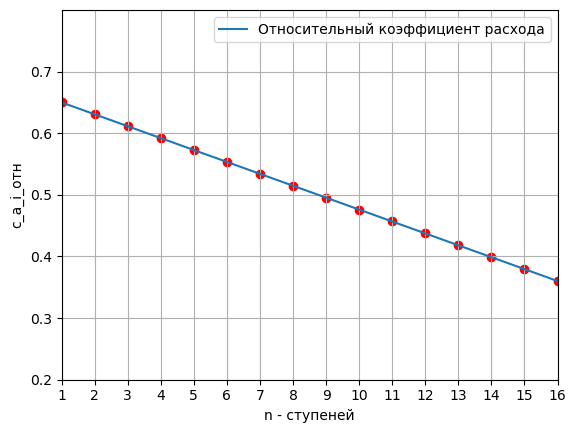

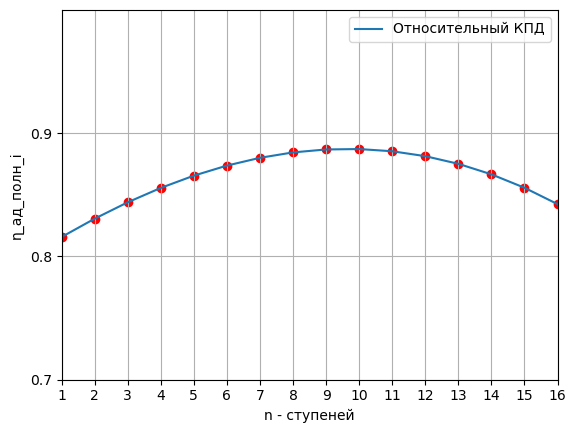

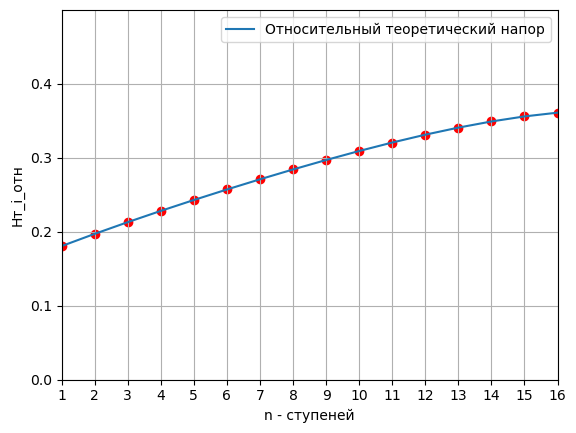

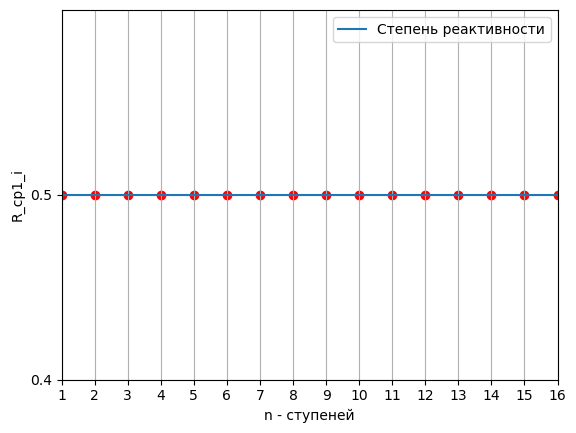

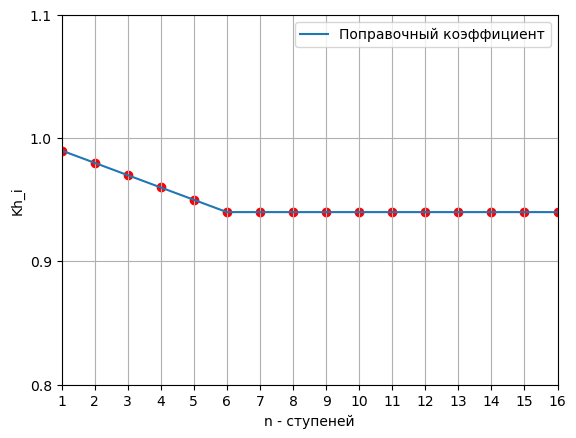

In [18]:
R_ср1_list = np.linspace(R_ср1, R_ср1, N)  # Создаем массив из N элементов, все равные R_ср1
Kh_i = np.concatenate([
    np.linspace(0.99, 0.94, 6),
    np.full((N-6), 0.94)
])

plot_results(N_list, c_a_i_отн, "Относительный коэффициент расхода", "c_a_i_отн")
plot_results(N_list, η_ад_полн_i, "Относительный КПД", "η_ад_полн_i")
plot_results(N_list, Hт_i_отн, "Относительный теоретический напор", "Hт_i_отн")
plot_results(N_list, R_ср1_list, "Степень реактивности", "R_ср1_i")
plot_results(N_list, Kh_i, "Поправочный коэффициент", "Kh_i")

In [19]:
# Расчет ВНА
# Коэффициент сохранения полного давления в ВНА
# Направление абсолютной скорости на входе в ВНА
σ_вх_вна = σ_in_gdf(ξ_вх, k_вх, ε_вх, λ_вх)
P1_полн_вна = σ_вх_вна * Pа_полн
c_1u_вна = c_u_отн_def(radius_отн(d1_отн), R_ср1, H_т1)
α_1_вна = math.radians(90)
α_2_вна = (math.atan(c_а1_отн / c_1u_отн))

α_1_вна_deg = np.degrees(α_1_вна)
α_2_вна_deg = np.degrees(α_2_вна)

In [20]:
c_2_вна_отн = c_а1_отн / np.sin(α_2_вна)
delta_c_abs_ВНА = np.abs(c_а1_отн * U_k1 - c_2_вна_отн * U_k1)  # Изменение скорости после ВНА 10-12 м/с должно быть

# 3. Поступенчатый расчет значений для каждой ступени

In [21]:
# Коэффициент расхода на выходе из ступени
# c_a_i_отн_plus_1 = np.concatenate((c_a_i_отн[1:], [c_a_i_отн[-1]])) Убрать потом формулу ниже и вернуть эту
c_a_i_отн_plus_1 = np.concatenate((c_a_i_отн[1:], [(c_a_i_отн[-1] - (c_a_i_отн[-2] - c_a_i_отн[-1]))]))
# Давление перед ступенями по длине компрессора
P1_полн_i = np.linspace(P1_полн, P2_полн, N)

# Температура перед ступенью по длине компрессора
T1_полн_i = np.linspace(T1_полн, T2_полн, N)

# Диаметры относительные по длине компрессора
d1_отн_i = np.linspace(d1_отн, d_n_отн, N)

# Окружные скорости по длине компрессора
if D_type == 'D_к_const':
    U_k_i = np.linspace(U_k1, U_k1, N)
else:
    U_k_i = np.linspace(U_k1, U_k2, N)

# Проверка: c_a не должна падать более чем на MAX_CA_DROP м/с между соседними ступенями
c_a_i_real = c_a_i_отн * U_k_i
if np.max(c_a_i_real[:-1] - c_a_i_real[1:]) > MAX_CA_DROP:
    print(f"Изменение скорости в ступени больше 12м/с")

# Начало расчета из Бекнева
# 1. Теоретический напор для i-й ступени:
Hт_i = Hт_i_отн * (U_k_i**2)

# 2. Действительная работа сжатия для i-й ступени:
L_z_i = Kh_i * Hт_i

# 3. Адиабатическая работа сжатия для i-й ступени:
H_ад_i = L_z_i * η_ад_полн_i

# Генерация c_p для каждой ступени через предзагруженную таблицу (Numba/Python fallback)
c_p_i = cp_lookup_array(P1_полн_i, T1_полн_i)

# Показатель адиабаты для каждой ступени через c_p_i
k_i = k_def(c_p_i, R_в)

# 4. Повышение полной температуры в ступени:
ΔT_полн_i = L_z_i / c_p_i # с_р в каждой ступени разный т.к. меняется температура

# 5. Полная температура на выходе из ступени:
T3_полн_i = T1_полн_i + ΔT_полн_i
T1_полн_i_plus_1 = T3_полн_i    # Температура на выходе становится температурой на входе в следующую ступень

# 6. Степень повышения полного давления:
π_полн_i = (1 + (H_ад_i / (c_p_i * T1_полн_i)))**(k_i/(k_i-1))

# 7. Полное давление на выходе из ступени:
P3_полн_i = P1_полн_i * π_полн_i 
P1_полн_i_plus_1 = P3_полн_i

k_i_plus_1 = np.concatenate((k_i[1:], [(k_i[-1] - (k_i[-2] - k_i[-1]))]))

# 8. Критическая скорость потока на входе и выходе:
a_кр_1_i = np.sqrt((2*k_i/(k_i+1))*R_в*T1_полн_i)
a_кр_3_i = np.sqrt((2*k_i_plus_1/(k_i_plus_1+1))*R_в*T3_полн_i)
    
# 9. Средний радиус на входе в i-ю ступень:
r_ср1_отн_i = np.sqrt( (1 + d1_отн_i**2) / 2)
    
# 10. Безразмерная окружная составляющая абсолютной скорости на входе в i-ю ступень:
c_u1_отн_i = r_ср1_отн_i * (1 - R_ср1) - (Hт_i_отн / (2 * r_ср1_отн_i))
    
# 11. Направление абсолютной скорости на входе
α_1_i = np.arctan(c_a_i_отн / c_u1_отн_i)
    
# 12. Приведенная скорость на входе
c_a1_i = c_a_i_отн * U_k_i
λ_1_i = c_a1_i / (np.sin(α_1_i) * a_кр_1_i)
    
# 13. ГДФ расхода
q_1_i = q_gdf(k_i, λ_1_i)

# 14. Кольцевая площадь на входе в ступень
F_1_i = (G_в * np.sqrt(R_в * T1_полн_i)) / (β * P1_полн_i * q_1_i * np.sin(α_1_i))

# 15. Кольцевая площадь на выходе из ступени F3
c_a3_отн_i = c_a_i_отн_plus_1
c_a3_i = c_a3_отн_i * U_k_i
λ_3_i_0 = c_a3_i / (np.sin(α_1_i) * a_кр_3_i)

q_3_i = q_gdf(k_i_plus_1, λ_3_i_0)
F_3_i_0 = F_1_i * ((q_1_i * P1_полн_i) / (q_3_i * P3_полн_i)) * np.sqrt(T3_полн_i / T1_полн_i)
    
# 16. Относительный диаметр втулки на выходе из ступени d3отн в первом прибляж для принятой ф. проточной части Dk = const
if D_type == 'D_к_const':
    # Dк = const

    D_к = D_к1
    # Диаметр втулки лопаток последнйей ступени:
    D_вт3_i_0 = np.sqrt(D_к**2 - ((4 * F_3_i_0) / np.pi))
    # Относительный диаметр втулки рабочего колеса последней ступени:
    d3_отн_i_0 = D_вт3_i_0 / D_к

elif D_type == 'D_вт_const':
    # Dвт = const

    D_вт = D_вт1
    D_к3_i_0 = np.sqrt(D_вт**2 + ((4 * F_3_i_0)/ np.pi))
    d3_отн_i_0 = D_вт / D_к3_i_0

else:
    # Dср = const

    D_ср = D_ср1
    D_к_n = np.sqrt(D_ср**2 + (2 * F_3_i_0 / math.pi))
    D_вт_n = np.sqrt(D_ср**2 - ((2 * F_3_i_0) / math.pi))
    d3_отн_i_0 = np.linspace(d1_отн, d1_отн, N)
    
# Относительный средний радиус на выходе из ступени
r_ср3_отн_i = np.sqrt( (1 + d3_отн_i_0**2) / 2)

# 17. Безразмерная окружная состовляющая абсолютной скорости на выходе
R_ср1_i_plus_1 = np.concatenate((R_ср1_list[1:], [R_ср1_list[-1]]))
# Hт_i_отн_plus_1 = np.concatenate((Hт_i_отн[1:], [Hт_i_отн[-1]])) # Убрать потом формулу ниже и вернуть эту
Hт_i_отн_plus_1 = np.concatenate((Hт_i_отн[1:], [(Hт_i_отн[-1] - (Hт_i_отн[-2] - Hт_i_отн[-1]))]))

c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_i_plus_1) - (Hт_i_отн / (2 * r_ср3_отн_i))

# 18. Направление потока в абсолютном движении после НА
α_3_i = np.atan(c_a3_отн_i / c_3u_отн_i)

# 19. Приведенная скорость на выходе
λ_3_i = c_a3_i / (np.sin(α_3_i) * a_кр_3_i)

# 20. Действительная кольцевая площадь на выходе из ступени
F_3_i = F_3_i_0 * ((q_gdf(k_i_plus_1, λ_3_i_0)) / (q_gdf(k_i_plus_1, λ_3_i)))
# F_1_i_plus_1 = np.concatenate((F_3_i[1:], [F_3_i[-1]])) Убрать потом формулу ниже и вернуть эту
F_1_i_plus_1 = np.concatenate((F_3_i[1:], [(F_3_i[-1] - (F_3_i[-2] - F_3_i[-1]))]))

# 21. Действительный относительный диаметр втулки d_3_отн подсчитывется в завис от типа проточн части.
if D_type == 'D_к_const':
    D_вт3_i = np.sqrt(D_к**2 - ((4 * F_3_i) / np.pi))
    d3_отн_i = D_вт3_i / D_к1
        
    # Ограничение на высоту лопатки
    h_lopatki = D_к - D_вт3_i[-1]
    if (h_lopatki < MIN_BLADE_HEIGHT) or (d3_отн_i[-1] > MAX_D3_REL):
        print(f"Непопадение в условия h_lopatki ({h_lopatki}) < {MIN_BLADE_HEIGHT} or d3_отн_i[-1] ({d3_отн_i[-1]}) > {MAX_D3_REL}")

elif D_type == 'D_вт_const':
    D_к3_i = np.sqrt(D_вт1**2 + ((4 * F_3_i)/ np.pi))
    d3_отн_i = D_вт / D_к3_i
    D_вт = D_вт1

    # Ограничение на высоту лопатки
    h_lopatki = D_к3_i[-1] - D_вт
    if (h_lopatki < MIN_BLADE_HEIGHT) or (d3_отн_i[-1] > MAX_D3_REL):
        print(f"Непопадение в условия h_lopatki ({h_lopatki}) < {MIN_BLADE_HEIGHT} or d3_отн_i[-1] ({d3_отн_i[-1]}) > {MAX_D3_REL}")
else:
    d3_отн_i = np.linspace(d1_отн, d1_отн, N)
    D_ср = D_ср1
    D_к_n = np.sqrt(D_ср**2 + (2 * F_3_i / math.pi))
    D_вт_n = np.sqrt(D_ср**2 - ((2 * F_3_i) / math.pi))

    # Ограничение на высоту лопатки
    h_lopatki = D_к_n[-1] - D_вт_n[-1]
    if (h_lopatki < MIN_BLADE_HEIGHT) or (d3_отн_i[-1] > MAX_D3_REL):
        print(f"Непопадение в условия h_lopatki ({h_lopatki}) < {MIN_BLADE_HEIGHT} or d3_отн_i[-1] ({d3_отн_i[-1]}) > {MAX_D3_REL}")

# 22. Средний радиус на выходе из ступени
r_ср3_отн_i = np.sqrt( (1 + d3_отн_i**2) / 2)

# 23. Средний радиус на выходе из рабочего колеса
r_ср2_отн_i = (r_ср1_отн_i + r_ср3_отн_i) / 2

# 24. Безразмерная окружная составляющая абсолютной скорости на выходе из рабочего колеса
c_u2_отн_i = (1 / r_ср2_отн_i) * (Hт_i_отн + c_u1_отн_i * r_ср1_отн_i)

# 25. Углы потока в относительном движении
β_1_i = np.atan((c_a_i_отн / (r_ср1_отн_i- c_u1_отн_i)))
c_a2_отн_i = (c_a_i_отн + c_a_i_отн_plus_1) / 2
β_2_i = np.atan((c_a2_отн_i / (r_ср2_отн_i- c_u2_отн_i)))
    
# 26. Направление потока в абсолютном движении после рабочего колеса
α_2_i = np.atan(c_a2_отн_i / c_u2_отн_i)
    
# 27. Углы поворота потока в средних сечениях лопаток РК и НА
ε_рк_i = β_2_i - β_1_i
ε_на_i = α_3_i - α_2_i

# 28. Относительная скорость на среднем радиусе на входе в РК
W_1_i = c_a1_i / np.sin(β_1_i)

# 29. Абсолютная скорость на среднем радиусе на входе в НА
c_a2_i = c_a2_отн_i * U_k_i
c_2_i = c_a2_i / np.sin(α_2_i)

# 30. Число Маха по относительной скорости на входе в РК
# ГДФ температуры на входе в РК
τ_1_i = (1 - (λ_1_i**2)*((k_i-1)/(k_i+1)))
# Статическая температура перед РК
T_1_i = T1_полн_i * τ_1_i
# Скорость звука на входе в РК
a_1_i = a_кр_def(k_i, R_в, T_1_i)

M_w1_i = W_1_i / a_1_i

# 31. Число Маха по абсолютной скорости на входе в НА
# Приведенная скорость перед НА
λ_c2_i = c_2_i / a_кр_3_i
# Статическая температура перед НА
T2_полн_i = T3_полн_i
k_i_ср = (k_i + k_i_plus_1)/2
τ_2_i = (1 - (λ_c2_i**2)*((k_i_plus_1-1)/(k_i_plus_1+1)))
T_2_i = T2_полн * τ_2_i
# Скорость звука на входе в НА
a_2_i = a_кр_def(k_i_ср, R_в, T_2_i)

M_c2_ср_i = c_2_i / a_2_i



# Надо перепроверить, нужно ли все, что ниже!!!!!!!!!!
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Абсолютная скорость на входе в РК
c_1_i = U_k_i * np.sqrt(c_a_i_отн**2 + c_u1_отн_i**2)
# Плотность заторможенного потока на выходе из ступени
ε_3_i = (1 - (k_i_plus_1-1)/(k_i_plus_1+1)*λ_3_i**2)**(1/(k_i_plus_1-1))
ρ3_i = ((P3_полн_i) / (R_в * T3_полн_i)) * ε_3_i
# Относительная скорость на среднем радиусе на входе в НА
W_2_i = c_a2_i / np.sin(β_2_i)

    
# Высота лопаток рабочего колеса
D_вт1_i = D_к * d1_отн_i
h_рк_i = 0.5 * (D_к - D_вт1_i)
    
# Относительный диаметр втулки на выходе из РК
d2_отн_i = np.sqrt(2 * (r_ср2_отн_i**2) - 1)
D_ср_1 = D_к * r_ср1_отн_i
D_ср_2 = D_к * r_ср2_отн_i
D_ср_3 = D_к * r_ср3_отн_i
    
# Периферийный диаметр на выходе из РК
D_вт2_i = D_к * d2_отн_i
D_вт1_i = D_к * d1_отн_i
    
# Высота лопаток НА
h_на_i = 0.5 * (D_к - D_вт2_i)
h_на_3_i = 0.5 * (D_к - D_вт3_i)



# Спрямляющий аппарат
# Критическая скорость потока на входе и выходе:
a_кр_1_i_СА = np.sqrt((2*k_i[-1]/(k_i[-1]+1))*R_в*T1_полн_i[-1])

# Средний радиус на входе в i-ю ступень:
r_ср1_отн_i_СА = np.sqrt( (1 + d1_отн_i[-1]**2) / 2)

# Абсолютная скорость на среднем радиусе на входе в НА:
c_a2_i_СА = c_a2_отн_i[-1] * U_k_i[-1]

# ГДФ расхода
q_1_i_СА = q_gdf(k_i[-1], λ_1_i[-1])

# Кольцевая площадь на входе в ступень:
F_1_i_СА = F_3_i[-1]

# Направление абсолютной скорости на выходе:
α_3_i_СА = np.radians(90)

# Действительная кольцевая площадь на выходе из ступени:
F_3_i_СА = F_1_i_СА

# Действительный относит. диаметр втулки на выходе из ступени
if D_type == 'D_к_const':
    D_вт3_i_СА = np.sqrt(D_к**2 - ((4 * F_3_i) / np.pi))
    d3_отн_i_СА = D_вт3_i_СА / D_к1

elif D_type == 'D_вт_const':
    D_к3_i_СА = np.sqrt(D_вт1**2 + ((4 * F_3_i)/ np.pi))
    d3_отн_i_СА = D_вт / D_к3_i_СА
    D_вт = D_вт1

else:
    d3_отн_i_СА = d1_отн
    D_ср = D_ср1
    D_к_n_СА = np.sqrt(D_ср**2 + (2 * F_3_i_СА / math.pi))
    D_вт_n_СА = np.sqrt(D_ср**2 - ((2 * F_3_i_СА) / math.pi))


# Средний радиус на выходе из ступени
r_ср3_отн_i_СА = np.sqrt( (1 + d3_отн_i_СА**2) / 2)

# Углы поворота потока в средних сеченияз лопаток РК и НА
α_2_i_СА = α_3_i[-1]
ε_на_i_СА = α_3_i_СА - α_2_i_СА

# Абсолютная скорость на среднем радиусе на входе в НА:
c_2_i_СА = c_a2_i_СА / np.sin(α_2_i_СА)

# Относительный диаметр втулки на выходе из РК:
d2_отн_i_СА = np.sqrt(2 * (r_ср2_отн_i[-1]**2) - 1)

# Втулочный диаметр на выходе из рабочего колеса:
D_вт2_i_СА = D_к * d2_отн_i_СА

# Высота лопаток НА:
h_на_i_СА = 0.5 * (D_к - D_вт2_i_СА)
h_на_3_i_СА = 0.5 * (D_к - D_вт3_i_СА)

Непопадение в условия h_lopatki (0.053447784986814684) < 0.02 or d3_отн_i[-1] (0.9214895519254134) > 0.92


In [22]:
π_ла_полн = P2_полн / P1_полн
η_ла_полн = (T1_полн * (π_ла_полн**((np.mean(k_i)-1)/np.mean(k_i)) - 1)) / (T2_полн - T1_полн)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k_вх, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k_вых, ε_вых, λ_вых)

π_к_полн = π_ла_полн * σ_вх * σ_вых

# Есть два варианта расчета кпд из учебника, будто 2 вариант круче
# !!!!!!!!!!!!!!!!!!!!!!!!!!
Tk_полн_new = T2_полн
T1_полн_new = Tа_полн

η_к_полн = np.sum(H_ад_i) / np.sum(L_z_i) - 0.02
N_к = G_в * np.sum(L_z_i)
print(f"""
π_ла_полн = {π_ла_полн}
η_ла_полн = {η_ла_полн}

π_ла_полн_0 = {π_ла_полн_0}
η_ла_полн_0 = {η_ла_полн_0}

π_к_полн = {π_к_полн:.4f}
η_к_полн = {η_к_полн:.4f}

π_к_полн_0 = {π_к_полн_0:.4f}
η_к_полн_0 = {η_к_полн_0:.4f}

N_к = {N_к}

N_stupeney = {N_stupeney}
""")


π_ла_полн = 18.466344832261523
η_ла_полн = 0.9015181189714336

π_ла_полн_0 = 18.43158405119445
η_ла_полн_0 = 0.8554219745078004

π_к_полн = 18.2000
η_к_полн = 0.8464

π_к_полн_0 = 18.2000
η_к_полн_0 = 0.8465

N_к = 23704731.637393102

N_stupeney = 16



In [23]:
# 1. Расширенный список всех переменных (включая СА)
list_names = [
    "σ_вх_вна", "P1_полн_вна", "c_1u_вна", "α_1_вна_deg", "α_2_вна_deg", "delta_c_abs_ВНА",
    "a_кр_1_i_СА", "r_ср1_отн_i_СА", "c_a2_i_СА", "q_1_i_СА", "F_1_i_СА", 
    "α_3_i_СА", "F_3_i_СА", "D_вт3_i_СА", "d3_отн_i_СА", "r_ср3_отн_i_СА", "α_2_i_СА", "ε_на_i_СА", 
    "c_2_i_СА", "d2_отн_i_СА", "D_вт2_i_СА", "h_на_i_СА", "h_на_3_i_СА",
    "k_i", "c_a_i_отн","c_a_i_отн_plus_1","P1_полн_i",
    "T1_полн_i","d1_отн_i","U_k_i","Hт_i","L_z_i","H_ад_i",
    "ΔT_полн_i","T3_полн_i","T1_полн_i_plus_1","π_полн_i",
    "P3_полн_i","P1_полн_i_plus_1","a_кр_1_i","a_кр_3_i",
    "r_ср1_отн_i","c_u1_отн_i","α_1_i","c_a1_i","λ_1_i",
    "q_1_i","F_1_i","c_a3_отн_i","c_a3_i","λ_3_i_0","q_3_i",
    "F_3_i_0","d3_отн_i_0","r_ср3_отн_i","c_3u_отн_i","α_3_i",
    "λ_3_i","F_3_i","F_1_i_plus_1","d3_отн_i","r_ср2_отн_i",
    "c_u2_отн_i","β_1_i","c_a2_отн_i","β_2_i","α_2_i","ε_рк_i",
    "ε_на_i","W_1_i","c_a2_i","c_2_i","τ_1_i","T_1_i","a_1_i",
    "M_w1_i","λ_c2_i","T2_полн_i","τ_2_i","T_2_i","a_2_i","M_c2_ср_i"
]

# Группировка для логики распределения по столбцам
vna_names = ["σ_вх_вна", "P1_полн_вна", "c_1u_вна", "α_1_вна_deg", "α_2_вна_deg", "delta_c_abs_ВНА"]
sa_names = [
    "a_кр_1_i_СА", "r_ср1_отн_i_СА", "c_a2_i_СА", "q_1_i_СА", "F_1_i_СА", 
    "α_3_i_СА", "F_3_i_СА", "D_вт3_i_СА", "d3_отн_i_СА", "r_ср3_отн_i_СА", "α_2_i_СА", "ε_на_i_СА", 
    "c_2_i_СА", "d2_отн_i_СА", "D_вт2_i_СА", "h_на_i_СА", "h_на_3_i_СА"
]

# Карта описаний
name_map = {
    "σ_вх_вна": "Коэффициент сохранения полного давления в ВНА", 
    "P1_полн_вна": "Полное давление в ВНА", 
    "c_1u_вна": "Окружная скорость в ВНА", 
    "α_1_вна_deg": "Угол входа в ВНА", 
    "α_2_вна_deg": "Угол выхода из ВНА",
    "delta_c_abs_ВНА": "Изменение скорости абсолютной в ВНА",
    "a_кр_1_i_СА": "СА: Критическая скорость на входе",
    "r_ср1_отн_i_СА": "СА: Относительный средний радиус на входе",
    "c_a2_i_СА": "СА: Осевая скорость на входе",
    "q_1_i_СА": "СА: ГДФ расхода на входе",
    "F_1_i_СА": "СА: Кольцевая площадь на входе",
    "α_3_i_СА": "СА: Угол абсолютной скорости на выходе",
    "F_3_i_СА": "СА: Действительная кольцевая площадь на выходе",
    "D_вт3_i_СА": "СА: Втулочный диаметр на выходе",
    "d3_отн_i_СА": "СА: Относительный диаметр втулки на выходе",
    "r_ср3_отн_i_СА": "СА: Относительный средний радиус на выходе",
    "α_2_i_СА": "СА: Угол абсолютной скорости на входе",
    "ε_на_i_СА": "СА: Диффузность решетки",
    "c_2_i_СА": "СА: Абсолютная скорость на входе",
    "d2_отн_i_СА": "СА: Относительный диаметр втулки на выходе РК",
    "D_вт2_i_СА": "СА: Втулочный диаметр на выходе РК",
    "h_на_i_СА": "СА: Высота лопаток на входе",
    "h_на_3_i_СА": "СА: Высота лопаток на выходе",
    "k_i": "Показатель адиабаты по длине компрессора перед РК",
    "c_a_i_отн": "Коэффициент расхода на входе в ступень",
    "c_a_i_отн_plus_1": "Коэффициент расхода на выходе из ступени",
    "P1_полн_i": "Полное давление перед ступенью",
    "T1_полн_i": "Полная температура перед ступенью",
    "d1_отн_i": "Относительный диаметр втулки на входе в ступень",
    "U_k_i": "Окружная скорость концов рабочих лопаток ступени",
    "Hт_i": "Теоретический напор i-й ступени",
    "L_z_i": "Действительная работа сжатия i-й ступени",
    "H_ад_i": "Адиабатическая работа сжатия i-й ступени",
    "ΔT_полн_i": "Повышение полной температуры в ступени",
    "T3_полн_i": "Полная температура на выходе из ступени",
    "T1_полн_i_plus_1": "Полная температура на входе в следующую ступень",
    "π_полн_i": "Степень повышения полного давления в ступени",
    "P3_полн_i": "Полное давление на выходе из ступени",
    "P1_полн_i_plus_1": "Полное давление перед следующей ступенью",
    "a_кр_1_i": "Критическая скорость потока на входе в ступень",
    "a_кр_3_i": "Критическая скорость потока на выходе из ступени",
    "r_ср1_отн_i": "Относительный средний радиус на входе в ступень",
    "c_u1_отн_i": "Безразмерная окружная составляющая скорости на входе",
    "α_1_i": "Угол абсолютной скорости на входе в РК",
    "c_a1_i": "Осевая скорость на входе в ступень",
    "λ_1_i": "Приведенная скорость на входе в ступень",
    "q_1_i": "Газодинамическая функция расхода на входе",
    "F_1_i": "Кольцевая площадь на входе в ступень",
    "c_a3_отн_i": "Коэффициент расхода на выходе из ступени",
    "c_a3_i": "Осевая скорость на выходе из ступени",
    "λ_3_i_0": "Приведенная скорость на выходе (1-е приближение)",
    "q_3_i": "Газодинамическая функция расхода на выходе",
    "F_3_i_0": "Кольцевая площадь на выходе (1-е приближение)",
    "d3_отн_i_0": "Относительный диаметр втулки на выходе (1-е приближение)",
    "r_ср3_отн_i": "Относительный средний радиус на выходе из ступени",
    "c_3u_отн_i": "Безразмерная окружная составляющая скорости на выходе",
    "α_3_i": "Угол абсолютной скорости на выходе из ступени",
    "λ_3_i": "Приведенная скорость на выходе из ступени",
    "F_3_i": "Действительная кольцевая площадь на выходе из ступени",
    "F_1_i_plus_1": "Кольцевая площадь на входе в следующую ступень",
    "d3_отн_i": "Относительный диаметр втулки на выходе из ступени",
    "r_ср2_отн_i": "Относительный средний радиус на выходе из РК",
    "c_u2_отн_i": "Безразмерная окружная составляющая скорости на выходе из РК",
    "β_1_i": "Угол относительной скорости на входе в РК",
    "c_a2_отн_i": "Относительная осевая скорость на выходе из РК",
    "β_2_i": "Угол относительной скорости на выходе из РК",
    "α_2_i": "Угол абсолютной скорости на выходе из РК",
    "ε_рк_i": "Диффузность решетки РК",
    "ε_на_i": "Диффузность решетки НА",
    "W_1_i": "Относительная скорость на входе в РК",
    "c_a2_i": "Осевая скорость на выходе из РК",
    "c_2_i": "Абсолютная скорость на выходе из РК",
    "τ_1_i": "Температурная функция на входе в РК",
    "T_1_i": "Статическая температура на входе в РК",
    "a_1_i": "Скорость звука на входе в РК",
    "M_w1_i": "Число Маха относительной скорости на входе в РК",
    "λ_c2_i": "Приведенная абсолютная скорость на выходе из РК",
    "T2_полн_i": "Полная температура на выходе из РК",
    "τ_2_i": "Температурная функция на выходе из РК",
    "T_2_i": "Статическая температура на выходе из РК",
    "a_2_i": "Скорость звука на выходе из РК",
    "M_c2_ср_i": "Среднее число Маха на выходе из РК"
}

def normalize_to_list(val):
    if isinstance(val, np.ndarray):
        return val.reshape(-1).tolist()
    if isinstance(val, (list, tuple)):
        return list(val)
    return [val]

def apply_uniform_autofit(ws):
    col_widths = {}
    for col_idx in range(1, ws.max_column + 1):
        max_len = 0
        for row_idx in range(1, ws.max_row + 1):
            value = ws.cell(row=row_idx, column=col_idx).value
            text = "" if value is None else str(value)
            for part in text.splitlines() or [""]:
                max_len = max(max_len, len(part))
        width = max(8, min(45, max_len + 2))
        col_widths[col_idx] = width
        ws.column_dimensions[get_column_letter(col_idx)].width = width

    align = Alignment(wrap_text=True, vertical="center", horizontal="center")
    for row_idx in range(1, ws.max_row + 1):
        max_lines = 1
        for col_idx in range(1, ws.max_column + 1):
            cell = ws.cell(row=row_idx, column=col_idx)
            text = "" if cell.value is None else str(cell.value)
            width = max(int(col_widths.get(col_idx, 10)) - 1, 1)
            lines = sum(max(1, math.ceil(len(p) / width)) for p in text.splitlines() or [""])
            max_lines = max(max_lines, lines)
            cell.alignment = align
            if isinstance(cell.value, (int, float)) and not isinstance(cell.value, bool):
                cell.number_format = "0.#####"
        ws.row_dimensions[row_idx].height = min(120, max(15, max_lines * 15))

# Сбор данных из глобальной видимости
values_by_var = {
    name: normalize_to_list(globals().get(name, []))
    for name in list_names
}

# Определение количества ступеней (исключая ВНА и СА)
stage_names = [n for n in list_names if n not in vna_names and n not in sa_names]
max_stage = max((len(values_by_var[n]) for n in stage_names), default=0)
stage_cols = [f"Ступень {i}" for i in range(1, max_stage + 1)]

rows = []

for name in list_names:
    values = values_by_var[name]
    
    row = {
        "Переменная": name,
        "Название": name_map.get(name, ""),
        "ВНА": np.nan,
        "СА": np.nan
    }

    # Если это переменная ВНА
    if name in vna_names:
        row["ВНА"] = values[0] if len(values) > 0 else np.nan
    
    # Если это переменная СА
    elif name in sa_names:
        row["СА"] = values[0] if len(values) > 0 else np.nan
    
    # Если это переменная ступеней
    else:
        for i, col in enumerate(stage_cols):
            row[col] = values[i] if i < len(values) else np.nan
    
    rows.append(row)

df = pd.DataFrame(rows)

# Формируем итоговый порядок колонок: Переменная, Название, ВНА, Ступени..., СА
cols_order = ["Переменная", "Название", "ВНА"] + stage_cols + ["СА"]
df = df[cols_order]

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")

display(df)

output_dir = "results"
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, "Поступенчатый_расчет_ступеней.xlsx")

with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Данные", index=False)
    apply_uniform_autofit(writer.sheets["Данные"])

print(f"Сохранено: {file_path}")

,Переменная,Название,ВНА,Ступень 1,Ступень 2,Ступень 3,Ступень 4,Ступень 5,Ступень 6,Ступень 7,Ступень 8,Ступень 9,Ступень 10,Ступень 11,Ступень 12,Ступень 13,Ступень 14,Ступень 15,Ступень 16,СА
0,σ_вх_вна,Коэффициент сохранения полного давления в ВНА,0.9901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P1_полн_вна,Полное давление в ВНА,1.003e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,c_1u_вна,Окружная скорость в ВНА,0.2225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,α_1_вна_deg,Угол входа в ВНА,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,α_2_вна_deg,Угол выхода из ВНА,71.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,delta_c_abs_ВНА,Изменение скорости абсолютной в ВНА,11.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,a_кр_1_i_СА,СА: Критическая скорость на входе,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,477.2
7,r_ср1_отн_i_СА,СА: Относительный средний радиус на входе,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9596
8,c_a2_i_СА,СА: Осевая скорость на входе,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.4
9,q_1_i_СА,СА: ГДФ расхода на входе,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4537


Сохранено: results/Поступенчатый_расчет_ступеней.xlsx


# 5. Расчет ступеней по высоте лопаток

In [24]:
# Втулочное сечение:
U_вт_1_i = U_k_i * d1_отн_i
U_вт_2_i = U_k_i * d2_отн_i

c_1u_вт_i = U_вт_1_i * c_u1_отн_i * (D_ср_1 / D_вт1_i)
c_2u_вт_i = U_вт_2_i * c_u2_отн_i * (D_ср_2 / D_вт2_i)
# c_3u_вт_i = np.concatenate([c_1u_вт_i[1:], c_1u_вт_i[-1:]]) Убрать потом формулу ниже и вернуть эту
c_3u_вт_i = np.concatenate([c_1u_вт_i[1:], [(c_1u_вт_i[-1] - (c_1u_вт_i[-2] - c_1u_вт_i[-1]))]])

U_1_ср_i = U_k_i * r_ср1_отн_i
U_k2_i = np.full(len(U_k_i), U_k1)

U_2_ср_i = U_k2_i * r_ср2_отн_i

c_a1_вт_i = c_a1_i
c_a2_вт_i = c_a2_i
# c_a3_вт_i = np.concatenate([c_a1_вт_i[1:], c_a1_вт_i[-1:]]) Убрать потом формулу ниже и вернуть эту
c_a3_вт_i = np.concatenate([c_a1_вт_i[1:], [(c_a1_вт_i[-1] - (c_a1_вт_i[-2] - c_a1_вт_i[-1]))]])

c_1_вт_i = np.sqrt(((c_a1_вт_i)**2) + ((c_1u_вт_i)**2))
c_1_вт_i = np.sqrt(((c_a2_вт_i)**2) + ((c_2u_вт_i)**2))
c_1_вт_i = np.sqrt(((c_a3_вт_i)**2) + ((c_3u_вт_i)**2))

α_1_вт_i = np.atan(c_a1_вт_i / c_1u_вт_i)
α_2_вт_i = np.atan(c_a2_вт_i / c_2u_вт_i)
α_3_вт_i = np.atan(c_a3_вт_i / c_3u_вт_i)

β_1_вт_i = np.atan(c_a1_вт_i / (U_вт_1_i - c_1u_вт_i))
β_2_вт_i = np.atan(c_a2_вт_i / (U_вт_2_i - c_2u_вт_i))

ε_вт_рк_i = β_2_вт_i - β_1_вт_i
ε_вт_на_i = α_3_вт_i - α_2_вт_i

In [25]:
# Периферийное сечение:
U_к_1_i = U_k_i
U_к_2_i = U_k_i

D_к1_i = np.full(len(U_k_i), D_к1)
D_к2_i = np.full(len(U_k_i), D_к1)

c_1u_к_i = U_к_1_i * c_u1_отн_i * (D_ср_1 / D_к1_i)
c_2u_к_i = U_к_2_i * c_u2_отн_i * (D_ср_2 / D_к2_i)
# c_3u_к_i = np.concatenate([c_1u_к_i[1:], c_1u_к_i[-1:]]) Убрать потом формулу ниже и вернуть эту
c_3u_к_i = np.concatenate([c_1u_к_i[1:], [(c_1u_к_i[-1] - (c_1u_к_i[-2] - c_1u_к_i[-1]))]])

U_1_ср_i = U_k_i * r_ср1_отн_i
U_k2_i = np.full(len(U_k_i), U_k1)

U_2_ср_i = U_k2_i * r_ср2_отн_i

c_a1_к_i = c_a1_i
c_a2_к_i = c_a2_i
# c_a3_к_i = np.concatenate([c_a1_к_i[1:], c_a1_к_i[-1:]]) Убрать потом формулу ниже и вернуть эту
c_a3_к_i = np.concatenate([c_a1_к_i[1:], [(c_a1_к_i[-1] - (c_a1_к_i[-2] - c_a1_к_i[-1]))]])

c_1_к_i = np.sqrt(((c_a1_к_i)**2) + ((c_1u_к_i)**2))
c_1_к_i = np.sqrt(((c_a2_к_i)**2) + ((c_2u_к_i)**2))
c_1_к_i = np.sqrt(((c_a3_к_i)**2) + ((c_3u_к_i)**2))

α_1_к_i = np.atan(c_a1_к_i / c_1u_к_i)
α_2_к_i = np.atan(c_a2_к_i / c_2u_к_i)
α_3_к_i = np.atan(c_a3_к_i / c_3u_к_i)

β_1_к_i = np.atan(c_a1_к_i / (U_к_1_i - c_1u_к_i))
β_2_к_i = np.atan(c_a2_к_i / (U_к_2_i - c_2u_к_i))

ε_к_рк_i = β_2_к_i - β_1_к_i
ε_к_на_i = α_3_к_i - α_2_к_i

W_1к_i = c_a1_к_i / (np.sin(β_1_к_i))
W_1вт_i = c_a1_вт_i / (np.sin(β_1_вт_i))

W_2к_i = c_a2_к_i / (np.sin(β_2_к_i))
W_2вт_i = c_a2_вт_i / (np.sin(β_2_вт_i))

a_1к_i = np.sqrt(k * R_в * T_1_i)
M_w1к_i = W_1к_i / a_1к_i

λ_w1к_i = W_1к_i / a_кр_1_i
λ_w1_i = W_1_i / a_кр_1_i
λ_w1вт_i = W_1вт_i / a_кр_1_i

In [26]:
import os
import numpy as np
import pandas as pd
import math
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter
D_ср1_i = (D_к1_i + D_вт1_i)/2
D_ср2_i = (D_к2_i + D_вт2_i)/2

list_names = [
    "U_вт_1_i","U_вт_2_i",
    "c_1u_вт_i","c_2u_вт_i","c_3u_вт_i",
    "U_1_ср_i","U_k2_i","U_2_ср_i",
    "c_a1_вт_i","c_a2_вт_i","c_a3_вт_i",
    "c_1_вт_i",
    "α_1_вт_i","α_2_вт_i","α_3_вт_i",
    "β_1_вт_i","β_2_вт_i",
    "ε_вт_рк_i","ε_вт_на_i",

    "U_к_1_i","U_к_2_i",
    "c_1u_к_i","c_2u_к_i","c_3u_к_i",
    "c_a1_к_i","c_a2_к_i","c_a3_к_i",
    "c_1_к_i",
    "α_1_к_i","α_2_к_i","α_3_к_i",
    "β_1_к_i","β_2_к_i",
    "ε_к_рк_i","ε_к_на_i",

    "W_1к_i","W_1вт_i",
    "W_2к_i","W_2вт_i",
    "a_1к_i","M_w1к_i",
    "λ_w1к_i","λ_w1_i","λ_w1вт_i"
]

name_map = {
    "U_вт_1_i": "Окружная скорость во втулочном сечении на входе",
    "U_вт_2_i": "Окружная скорость во втулочном сечении на выходе",
    "c_1u_вт_i": "Окружная составляющая абсолютной скорости (втулка), вход",
    "c_2u_вт_i": "Окружная составляющая абсолютной скорости (втулка), выход из РК",
    "c_3u_вт_i": "Окружная составляющая абсолютной скорости (втулка), выход из ступени",
    "U_1_ср_i": "Окружная скорость в среднем сечении на входе",
    "U_k2_i": "Окружная скорость концов лопаток на выходе",
    "U_2_ср_i": "Окружная скорость в среднем сечении на выходе",
    "c_a1_вт_i": "Осевая скорость (втулка), вход",
    "c_a2_вт_i": "Осевая скорость (втулка), выход из РК",
    "c_a3_вт_i": "Осевая скорость (втулка), выход из ступени",
    "c_1_вт_i": "Абсолютная скорость (втулка) на входе",
    "α_1_вт_i": "Угол абсолютной скорости (втулка) на входе",
    "α_2_вт_i": "Угол абсолютной скорости (втулка) на выходе из РК",
    "α_3_вт_i": "Угол абсолютной скорости (втулка) на выходе из ступени",
    "β_1_вт_i": "Угол относительной скорости (втулка) на входе в РК",
    "β_2_вт_i": "Угол относительной скорости (втулка) на выходе из РК",
    "ε_вт_рк_i": "Диффузность решетки РК во втулочном сечении",
    "ε_вт_на_i": "Диффузность решетки НА во втулочном сечении",
    "U_к_1_i": "Окружная скорость в периферийном сечении на входе",
    "U_к_2_i": "Окружная скорость в периферийном сечении на выходе",
    "c_1u_к_i": "Окружная составляющая абсолютной скорости (периферия), вход",
    "c_2u_к_i": "Окружная составляющая абсолютной скорости (периферия), выход из РК",
    "c_3u_к_i": "Окружная составляющая абсолютной скорости (периферия), выход из ступени",
    "c_a1_к_i": "Осевая скорость (периферия), вход",
    "c_a2_к_i": "Осевая скорость (периферия), выход из РК",
    "c_a3_к_i": "Осевая скорость (периферия), выход из ступени",
    "c_1_к_i": "Абсолютная скорость (периферия) на входе",
    "α_1_к_i": "Угол абсолютной скорости (периферия) на входе",
    "α_2_к_i": "Угол абсолютной скорости (периферия) на выходе из РК",
    "α_3_к_i": "Угол абсолютной скорости (периферия) на выходе из ступени",
    "β_1_к_i": "Угол относительной скорости (периферия) на входе в РК",
    "β_2_к_i": "Угол относительной скорости (периферия) на выходе из РК",
    "ε_к_рк_i": "Диффузность решетки РК в периферийном сечении",
    "ε_к_на_i": "Диффузность решетки НА в периферийном сечении",
    "W_1к_i": "Относительная скорость на входе в РК (периферия)",
    "W_1вт_i": "Относительная скорость на входе в РК (втулка)",
    "W_2к_i": "Относительная скорость на выходе из РК (периферия)",
    "W_2вт_i": "Относительная скорость на выходе из РК (втулка)",
    "a_1к_i": "Скорость звука на входе в РК (периферия)",
    "M_w1к_i": "Число Маха относительной скорости на входе (периферия)",
    "λ_w1к_i": "Приведенная относительная скорость на входе (периферия)",
    "λ_w1_i": "Приведенная относительная скорость на входе (среднее сечение)",
    "λ_w1вт_i": "Приведенная относительная скорость на входе (втулка)"
}


def normalize_to_list(val):
    if isinstance(val, np.ndarray):
        if val.ndim == 1:
            return val.tolist()
        return val.reshape(-1).tolist()
    if isinstance(val, (list, tuple)):
        return list(val)
    return [val]


def short_name(name: str) -> str:
    for suffix in ("_i_plus_1", "_i_0", "_i"):
        if name.endswith(suffix):
            return name[:-len(suffix)]
    return name


def apply_uniform_autofit(ws):
    col_widths = {}

    # 1) Ширина каждой колонки отдельно (компактно + без обрезки)
    for col_idx in range(1, ws.max_column + 1):
        max_len = 0
        for row_idx in range(1, ws.max_row + 1):
            value = ws.cell(row=row_idx, column=col_idx).value
            text = "" if value is None else str(value)
            for part in text.splitlines() or [""]:
                if len(part) > max_len:
                    max_len = len(part)

        # Ограничиваем, чтобы лист оставался компактным
        width = max(8, min(45, max_len + 2))
        col_widths[col_idx] = width
        ws.column_dimensions[get_column_letter(col_idx)].width = width

    align = Alignment(wrap_text=True, vertical="center", horizontal="center")

    # 2) Высота каждой строки отдельно по реальному содержимому
    for row_idx in range(1, ws.max_row + 1):
        max_lines = 1

        for col_idx in range(1, ws.max_column + 1):
            cell = ws.cell(row=row_idx, column=col_idx)
            text = "" if cell.value is None else str(cell.value)
            width = max(int(col_widths.get(col_idx, 10)) - 1, 1)

            lines_for_cell = 0
            parts = text.splitlines() or [""]
            for part in parts:
                lines_for_cell += max(1, math.ceil(len(part) / width))

            if lines_for_cell > max_lines:
                max_lines = lines_for_cell

            cell.alignment = align
            if isinstance(cell.value, (int, float)) and not isinstance(cell.value, bool):
                cell.number_format = "0.#####"

        ws.row_dimensions[row_idx].height = min(120, max(15, max_lines * 15))
values_by_var = {}
for name in list_names:
    values_by_var[name] = normalize_to_list(globals().get(name, []))

max_stage = max((len(v) for v in values_by_var.values()), default=0)
stage_cols = [f"Ступень {i}" for i in range(1, max_stage + 1)]

rows = []
for name in list_names:
    values = values_by_var[name]
    row = {
        "Переменная": name,
        "Название (из комментария)": name_map.get(name, ""),
    }
    for i, col in enumerate(stage_cols):
        row[col] = values[i] if i < len(values) else np.nan
    rows.append(row)

df = pd.DataFrame(rows) if rows else pd.DataFrame({
    "Переменная": ["Нет данных"],
    "Название (из комментария)": [""],
})

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

display(df)

output_dir = "results"
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, "Расчет_ступеней_по_высоте_лопаток.xlsx")

with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Данные", index=False)
    apply_uniform_autofit(writer.sheets["Данные"])

print(f"Сохранено: {file_path}")





,Переменная,Название (из комментария),Ступень 1,Ступень 2,Ступень 3,Ступень 4,Ступень 5,Ступень 6,Ступень 7,Ступень 8,Ступень 9,Ступень 10,Ступень 11,Ступень 12,Ступень 13,Ступень 14,Ступень 15,Ступень 16
0,U_вт_1_i,Окружная скорость во втулочном сечении на входе,131.8,141.8,151.7,161.7,171.7,181.6,191.6,201.5,211.5,221.4,231.4,241.4,251.3,261.3,271.2,281.2
1,U_вт_2_i,Окружная скорость во втулочном сечении на выходе,144,197.8,213.1,222.1,228.8,234.5,239.8,244.8,249.7,254.4,259.1,263.8,268.4,272.9,277.4,281.8
2,c_1u_вт_i,Окружная составляющая абсолютной скорости (вту...,63.13,62.82,62.77,62.98,63.44,64.12,65.04,66.19,67.59,69.24,71.16,73.37,75.91,78.79,82.07,85.78
3,c_2u_вт_i,Окружная составляющая абсолютной скорости (вту...,118.5,123.2,128.1,132.9,137.9,143,148.1,153.3,158.6,164,169.5,174.9,180.4,185.8,191.2,196.5
4,c_3u_вт_i,Окружная составляющая абсолютной скорости (вту...,62.82,62.77,62.98,63.44,64.12,65.04,66.19,67.59,69.24,71.16,73.37,75.91,78.79,82.07,85.78,89.49
5,U_1_ср_i,Окружная скорость в среднем сечении на входе,236,238.8,241.9,245.1,248.4,251.9,255.6,259.4,263.3,267.4,271.6,275.9,280.3,284.8,289.4,294.1
6,U_k2_i,Окружная скорость концов лопаток на выходе,306.5,306.5,306.5,306.5,306.5,306.5,306.5,306.5,306.5,306.5,306.5,306.5,306.5,306.5,306.5,306.5
7,U_2_ср_i,Окружная скорость в среднем сечении на выходе,239.5,258,264,267.7,270.5,272.9,275.2,277.4,279.6,281.7,283.8,286,288.1,290.2,292.3,294.5
8,c_a1_вт_i,"Осевая скорость (втулка), вход",199.3,193.3,187.4,181.5,175.6,169.6,163.7,157.8,151.8,145.9,140,134.1,128.1,122.2,116.3,110.4
9,c_a2_вт_i,"Осевая скорость (втулка), выход из РК",196.3,190.4,184.4,178.5,172.6,166.7,160.7,154.8,148.9,143,137,131.1,125.2,119.2,113.3,107.4


Сохранено: results/Расчет_ступеней_по_высоте_лопаток.xlsx


# 4. Профилирование решеток

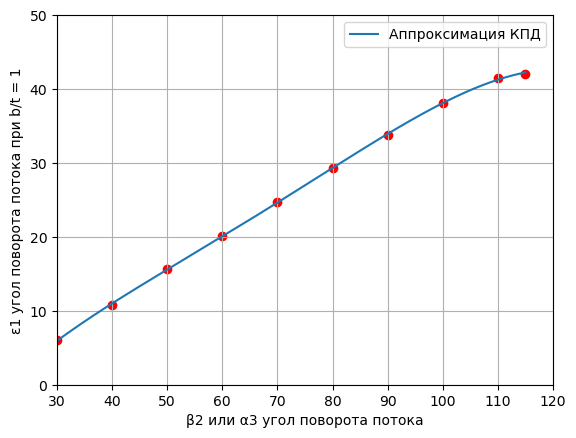

In [27]:
# График с учебника рис. 4

# Точки
β_2_dots = np.array([30, 40, 50, 60, 70, 80, 90, 100, 110, 115])       # точки по оси X для теоретического напора
ε_b_ε_dots = np.array([6, 10.85, 15.65, 20.1, 24.71, 29.31, 33.8, 38.1, 41.5, 42.1])      # точки по оси Y для теоретического напора

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(β_2_dots, ε_b_ε_dots, stepen)
poly = np.poly1d(coeffs)

smoothness = 100000     # Число точек

β_2_dots_smooth = np.linspace(min(β_2_dots), max(β_2_dots), smoothness)
ε_b_ε_dots_smooth = poly(β_2_dots_smooth)

plt.plot(β_2_dots_smooth, ε_b_ε_dots_smooth, label="Аппроксимация КПД")
plt.scatter(β_2_dots, ε_b_ε_dots, color="red")
plt.xlim(30,120)
plt.ylim(0, 50)
plt.xticks(np.arange(30, 130, 10))  # Установка делений по оси X с шагом 10
plt.yticks(np.arange(0, 60, 10))  # Установка делений по оси Y с шагом 10
plt.xlabel("β2 или α3 угол поворота потока")
plt.ylabel("ε1 угол поворота потока при b/t = 1")
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()
plt.close()

ε_1_x_line = β_2_dots_smooth
ε_1_y_line = ε_b_ε_dots_smooth

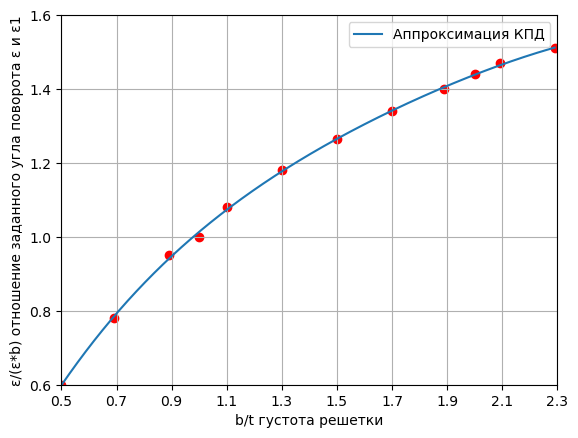

In [28]:
# График с учебника рис. 4

# Точки
b_t_dots = np.array([0.5, 0.69, 0.89, 1.0, 1.1, 1.3, 1.5, 1.7, 1.89, 2.0, 2.09, 2.29])       # точки по оси X для теоретического напора
ε__b_ε_dots = np.array([0.6, 0.78, 0.95, 1.0, 1.08, 1.18, 1.265, 1.34, 1.4, 1.44, 1.47, 1.51])      # точки по оси Y для теоретического напора

#b_t_dots = np.array([0.5, 1.0, 1.5,2.0, 2.29])       # точки по оси X для теоретического напора
#ε__b_ε_dots = np.array([0.6, 1.0, 1.265, 1.44, 1.51])      # точки по оси Y для теоретического напора


# аппроксимация полиномом степени stepen
stepen = 4
coeffs1 = np.polyfit(b_t_dots, ε__b_ε_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000     # Число точек

b_t_dots_smooth = np.linspace(min(b_t_dots), max(b_t_dots), smoothness)
ε__b_ε_dots_smooth = poly1(b_t_dots_smooth)

plt.plot(b_t_dots_smooth, ε__b_ε_dots_smooth, label="Аппроксимация КПД")
plt.scatter(b_t_dots, ε__b_ε_dots, color="red")
plt.xlim(0.5,2.3)
plt.ylim(0.6, 1.6)
plt.xticks(np.arange(0.5, 2.4, 0.2))  # Установка делений по оси X с шагом 0.2
plt.yticks(np.arange(0.6, 1.7, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.xlabel("b/t густота решетки")
plt.ylabel("ε/(ε*b) отношение заданного угла поворота ε и ε1")
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()
plt.close()

ε_отн_x_line = b_t_dots_smooth
ε_отн_y_line = ε__b_ε_dots_smooth

In [29]:
β_1_i = np.degrees(β_1_i)
β_2_i = np.degrees(β_2_i)
α_2_i = np.degrees(α_2_i)
α_3_i = np.degrees(α_3_i)
ε_рк_i = np.degrees(ε_рк_i)
ε_на_i = np.degrees(ε_на_i)
ε_к_рк_i = np.degrees(ε_к_рк_i)
ε_к_на_i = np.degrees(ε_к_на_i)
ε_вт_рк_i = np.degrees(ε_вт_рк_i)
ε_вт_на_i = np.degrees(ε_вт_на_i)

In [30]:
# 1.
# Рабочее колесо
ε_РК_x, ε_РК_i= find_nearest(β_2_i, ε_1_x_line, ε_1_y_line)
bt_1_x, bt_1ср_i= find_nearest((ε_рк_i / ε_РК_i), ε_отн_x_line, ε_отн_y_line)

# Направляющий аппарат
ε_НА_x, ε_НА_i= find_nearest(α_3_i, ε_1_x_line, ε_1_y_line)
bt_2_x, bt_2ср_i= find_nearest((ε_на_i / ε_НА_i), ε_отн_x_line, ε_отн_y_line)

In [31]:
# Углы атаки
i_рк_i = (2.5 * (bt_1ср_i - 1))  # Угол атаки для РК. Тут умножается на deg
i_на_i = (2.5 * (bt_2ср_i - 2))  # Угол атаки для РК

# Коэффициент учитывающий форму средней линии дуги профиля
X_f_отн = 0.5   #  Может быть 0.45 для параболической формы
m_рк_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * β_2_i # Тут делится на deg
m_на_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * α_3_i

θ_рк_i = (np.radians(ε_рк_i - i_рк_i) / (1 - m_рк_i * np.sqrt(1 / bt_1ср_i)))
θ_на_i = (np.radians(ε_на_i - i_на_i) / (1 - m_на_i * np.sqrt(1 / bt_2ср_i)))

if X_f_отн == 0.5:      # Дуга окружности
    χ_рк_i = 0.5 * θ_рк_i
    χ_на_i = 0.5 * θ_на_i
elif X_f_отн == 0.45:   # Параболическая средняя линия
    χ_рк_i = 0.6 * θ_рк_i
    χ_на_i = 0.6 * θ_на_i

v_рк_i = χ_рк_i + β_1_i + i_рк_i
v_на_i = χ_на_i + α_2_i + i_на_i

In [32]:
# Алгоритм подбора параметров для уникальности Z_рк_i и Z_на_i

# Диапазоны параметров для перебора
bt_1к_range = np.arange(1.05, 1.30, 0.01)  # bt_1к_i_отн_нужн от 1.05 до 1.30
bt_2к_range = np.arange(1.05, 1.30, 0.01)  # bt_2к_i_отн_нужн от 1.05 до 1.30
h_рк_start_range = np.arange(3.5, 4.0, 0.1)  # начальное значение h_рк_i_отн
h_на_start_range = np.arange(3.5, 4.0, 0.1)  # начальное значение h_на_i_отн

found = False
for bt_1к_i_отн_нужн in bt_1к_range:
    for bt_2к_i_отн_нужн in bt_2к_range:
        for h_рк_start in h_рк_start_range:
            for h_на_start in h_на_start_range:
                # Задаём удлинение лопаток
                h_рк_i_отн = h_рк_start + (-0.1) * np.arange(N_stupeney)
                h_на_i_отн = h_на_start + (-0.1) * np.arange(N_stupeney)
                
                # Хорды лопаток
                b_рк_i_test = h_рк_i / h_рк_i_отн
                b_на_i_test = h_на_i / h_на_i_отн
                
                # Число лопаток из условия на периферии
                Z_рк_i_test = np.ceil(np.pi * D_к1_i / b_рк_i_test * bt_1к_i_отн_нужн).astype(int)
                Z_рк_i_test[Z_рк_i_test % 2 == 0] += 1  # Делаем нечётными
                
                Z_на_i_test = np.ceil(np.pi * D_к2_i / b_на_i_test * bt_2к_i_отн_нужн).astype(int)
                Z_на_i_test[Z_на_i_test % 2 != 0] += 1  # Делаем чётными
                
                # Проверяем уникальность
                if (len(np.unique(Z_рк_i_test)) == N_stupeney) and (len(np.unique(Z_на_i_test)) == N_stupeney):
                    bt_1к_i_отн_нужн = bt_1к_i_отн_нужн
                    bt_2к_i_отн_нужн = bt_2к_i_отн_нужн
                    h_рк_i_отн = h_рк_i_отн
                    h_на_i_отн = h_на_i_отн
                    b_рк_i = b_рк_i_test
                    b_на_i = b_на_i_test
                    Z_рк_i = Z_рк_i_test
                    Z_на_i = Z_на_i_test
                    found = True
                    print("Параметры подобраны!")
                    print(f"bt_1к_i_отн_нужн = {bt_1к_i_отн_нужн:.3f}")
                    print(f"bt_2к_i_отн_нужн = {bt_2к_i_отн_нужн:.3f}")
                    print(f"h_рк_i_отн[0] = {h_рк_i_отн[0]:.2f}")
                    print(f"h_на_i_отн[0] = {h_на_i_отн[0]:.2f}")
                    break
            if found:
                break
        if found:
            break
    if found:
        break

if not found:
    raise ValueError("Не удалось подобрать параметры для уникальных Z")

print(f"\nZ_рк_i = {Z_рк_i}")
print(f"Уникальных Z_рк_i: {len(np.unique(Z_рк_i))}")
print(f"\nZ_на_i = {Z_на_i}")
print(f"Уникальных Z_на_i: {len(np.unique(Z_на_i))}")

R_сл_рк_i = b_рк_i / (2 * np.sin(np.radians(θ_рк_i) / 2))
R_сл_на_i = b_на_i / (2 * np.sin(np.radians(θ_на_i) / 2))

t_ср_рк_i = b_рк_i / bt_1ср_i
t_ср_на_i = b_на_i / bt_2ср_i

Параметры подобраны!
bt_1к_i_отн_нужн = 1.050
bt_2к_i_отн_нужн = 1.050
h_рк_i_отн[0] = 3.70
h_на_i_отн[0] = 3.50

Z_рк_i = [ 43  45  47  49  51  53  55  59  63  67  73  81  93 109 133 177]
Уникальных Z_рк_i: 16

Z_на_i = [ 44  64  72  78  82  86  88  92  98 102 108 114 122 134 146 164]
Уникальных Z_на_i: 16


In [33]:
# Корректируем значения шага и густоты решетки всязи с увеличением числа лопаток

t_ср_рк_i = np.pi * D_к_i * r_ср2_отн_i / Z_рк_i
bt_1ср_i = b_рк_i / t_ср_рк_i

t_ср_на_i = np.pi * D_к_i * r_ср2_отн_i / Z_на_i
bt_2ср_i = b_на_i / t_ср_на_i

i_рк_i = (2.5 * (bt_1ср_i - 1))  # Угол атаки для РК
i_на_i = (2.5 * (bt_2ср_i - 2))  # Угол атаки для НА

θ_рк_i = (np.radians(ε_рк_i - i_рк_i) / (1 - m_рк_i * np.sqrt(1 / bt_1ср_i)))
θ_на_i = (np.radians(ε_на_i - i_на_i) / (1 - m_на_i * np.sqrt(1 / bt_2ср_i)))

if X_f_отн == 0.5:      # Дуга окружности
    χ_рк_i = 0.5 * θ_рк_i
    χ_на_i = 0.5 * θ_на_i
elif X_f_отн == 0.45:   # Параболическая средняя линия
    χ_рк_i = 0.6 * θ_рк_i
    χ_на_i = 0.6 * θ_на_i

v_рк_i = χ_рк_i + β_1_i + i_рк_i
v_на_i = χ_на_i + α_2_i + i_на_i

R_сл_рк_i = b_рк_i / (2 * np.sin(np.radians(θ_рк_i) / 2))
R_сл_на_i = b_на_i / (2 * np.sin(np.radians(θ_на_i) / 2))

In [34]:
# Периферийный радиус
t_к_рк_i = np.pi * D_к1_i / Z_рк_i
t_к_на_i = np.pi * D_к2_i / Z_на_i

bt_1к_i_отн = b_рк_i / t_к_рк_i
bt_2к_i_отн = b_на_i / t_к_на_i

i_рк_к_i = (2.5 * (bt_1к_i_отн - 1))  # Угол атаки для РК
i_на_к_i = (2.5 * (bt_2к_i_отн - 2))  # Угол атаки для НА

m_рк_к_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * np.degrees(β_2_к_i)
m_на_к_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * np.degrees(α_3_к_i)

θ_рк_к_i = (np.radians(ε_к_рк_i- i_рк_к_i) / (1 - m_рк_к_i * np.sqrt(1 / bt_1к_i_отн)))
θ_на_к_i = (np.radians(ε_к_на_i - i_на_к_i) / (1 - m_на_к_i * np.sqrt(1 / bt_2к_i_отн)))

δ_рк_к_i = m_рк_к_i * θ_рк_к_i * np.sqrt(b_рк_i / t_к_рк_i)
δ_на_к_i = m_на_к_i * θ_на_к_i * np.sqrt(b_на_i / t_к_на_i)

if X_f_отн == 0.5:      # Дуга окружности
    χ_рк_к_i = 0.5 * θ_рк_к_i
    χ_на_к_i = 0.5 * θ_на_к_i
elif X_f_отн == 0.45:   # Параболическая средняя линия
    χ_рк_к_i = 0.6 * θ_рк_к_i
    χ_на_к_i = 0.6 * θ_на_к_i

v_рк_к_i = χ_рк_к_i + np.degrees(β_1_к_i) + i_рк_к_i
v_на_к_i = χ_на_к_i + np.degrees(α_2_к_i) + i_на_к_i

In [35]:
# Втулочный радиус
t_вт_рк_i = np.pi * D_вт1_i / Z_рк_i # Шаг лопаток у втулки РК
t_вт_на_i = np.pi * D_вт2_i / Z_на_i # Шаг лопаток у втулки НА

bt_1вт_i_отн = b_рк_i / t_вт_рк_i   # Густота у втулки в РК
bt_2вт_i_отн = b_на_i / t_вт_на_i   # Густота у втулки в НА

i_рк_вт_i = (2.5 * (bt_1вт_i_отн - 1))  # Угол атаки для РК
i_на_вт_i = (2.5 * (bt_2вт_i_отн - 2))  # Угол атаки для НА

m_рк_вт_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * np.degrees(β_2_вт_i)
m_на_вт_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * np.degrees(α_3_вт_i)

θ_рк_вт_i = (np.radians(ε_вт_рк_i - i_рк_вт_i) / (1 - m_рк_вт_i * np.sqrt(1 / bt_1вт_i_отн)))   # Угол поворота потока у втулки РК
θ_на_вт_i = (np.radians(ε_вт_на_i - i_на_вт_i) / (1 - m_на_вт_i * np.sqrt(1 / bt_2вт_i_отн)))   # Угол поворота потока у втулки НА

δ_рк_вт_i = m_рк_вт_i * θ_рк_вт_i * np.sqrt(b_рк_i / t_вт_рк_i)
δ_на_вт_i = m_на_вт_i * θ_на_вт_i * np.sqrt(b_на_i / t_вт_на_i)

if X_f_отн == 0.5:      # Дуга окружности
    χ_рк_вт_i = 0.5 * θ_рк_вт_i
    χ_на_вт_i = 0.5 * θ_на_вт_i
elif X_f_отн == 0.45:   # Параболическая средняя линия
    χ_рк_вт_i = 0.6 * θ_рк_вт_i
    χ_на_вт_i = 0.6 * θ_на_вт_i

v_рк_вт_i = χ_рк_вт_i + np.degrees(β_1_вт_i) + i_рк_вт_i    # Угол установки лопатки у втулки РК
v_на_вт_i = χ_на_вт_i + np.degrees(α_2_вт_i) + i_на_вт_i    # Угол установки лопатки у втулки НА

R_сл_рк_вт_i = b_рк_i / (2 * np.sin(np.radians(θ_рк_вт_i) / 2)) # Радиус дуги средней линии у втулки РК
R_сл_на_вт_i = b_на_i / (2 * np.sin(np.radians(θ_на_вт_i) / 2)) # Радиус дуги средней линии у втулки НА

In [36]:
# Профилирование первой ступени
S_1_i = 0.25 * b_рк_i
S_2_i = 0.25 * b_на_i
S_1_sum = np.sum(S_1_i)
S_2_sum = np.sum(S_2_i)

S_в_РК_i = b_рк_i * np.sin(np.radians(v_рк_вт_i))   # Ширина РК в меридиональной плоскости
S_в_НА_i = b_на_i * np.sin(np.radians(v_на_вт_i))   # Ширина НА в меридиональной плоскости

S_ср_РК_i = b_рк_i * np.sin(np.radians(v_рк_i))     # Ширина РК в средней плоскости
S_ср_НА_i = b_на_i * np.sin(np.radians(v_на_i))     # Ширина НА в средней плоскости

S_к_РК_i = b_рк_i * np.sin(np.radians(v_рк_к_i))    # Ширина РК в периферийной плоскости
S_к_НА_i = b_на_i * np.sin(np.radians(v_на_к_i))    # Ширина НА в периферийной плоскости



# Логика получения общей длины компрессора
S_в_sum = np.sum(S_в_РК_i) + np.sum(S_в_НА_i)
S_ср_sum = np.sum(S_ср_РК_i) +  np.sum(S_ср_НА_i)
S_к_sum = np.sum(S_к_РК_i) + np.sum(S_к_НА_i)
max_S = np.max([S_в_sum, S_ср_sum, S_к_sum])
Length_all_compressor = np.sum(S_1_i) + np.sum(S_2_i) + max_S

print(f"Length_all_compressor = {Length_all_compressor}")
print(f"{max_S} = ({S_в_sum}, {S_ср_sum}, {S_к_sum})")

Length_all_compressor = 0.9877091301536262
0.7436865007674203 = (0.7436865007674203, 0.6571662962216811, 0.6049084905122832)


# Профилирование лопаток

In [37]:
def coordinates_to_file(x_coord_list, y_coord_list, name, folder):
    x_coord_list = list(x_coord_list * 10**3)
    y_coord_list = list(y_coord_list * 10**3)
    # Формируем полный путь к директории
    base_path = os.path.join('Dots_results', folder)
    os.makedirs(base_path, exist_ok=True)
    
    # Объединяем base_path и имя файла
    file_path = os.path.join(base_path, f"{name}.txt")
    
    with open(file_path, 'w', encoding='utf-8') as f:
        for x, y in zip(x_coord_list, y_coord_list):
            f.write(f"{x}\t{y}\n")


In [38]:
# Среднее сечение
# Исходный профиль А-40

x_b_A40 = np.array([1, 1.5, 2.5, 5, 7.5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 95, 100]) * 10**(-2)
y_b_A40 = np.array([1.14, 1.43, 1.85, 2.55, 3.09, 3.525, 4.16, 4.55, 4.788, 4.927, 4.936, 5, 4.858, 4.442, 3.783, 2.85, 1.722, 1.003, 0]) * 10**(-2)

def matrix_gen(len_A_40, len_θ):
    for _ in range(len_θ):
        yield [0] * len_A_40

def np_cot(num):
    return (1/np.tan(num))

def np_acot(num):
    return (1 / np.atan(num))

In [39]:
def dots_creating_form(x_b_A40, y_b_A40, θ_рк_i, θ_на_i, b_рк_i, b_на_i, c_a1_i, c_a2_i, c_a3_i, β_1_i, β_2_i, α_3_i, α_2_i, bt_1ср_i, bt_2ср_i):
    # Среднее сечение
    # Относительные координаты точек средней линии лопаток
    y_b_СР_сл_РК_i = list(matrix_gen((len(y_b_A40)), (len(θ_рк_i))))    # Создание пустого списка
    for i, θ_рк_num in enumerate(θ_рк_i):
        y_b_СР_сл_РК_i[i] = np.sqrt(1/4 * (np_cot(θ_рк_num / 2))**2 + x_b_A40 * (1 - x_b_A40)) - 1/2 * (np_cot(θ_рк_num / 2))
    y_b_СР_сл_РК_i = np.array(y_b_СР_сл_РК_i)

    y_b_СР_сл_НА_i = list(matrix_gen((len(y_b_A40)), (len(θ_на_i))))    # Создание пустого списка
    for i, θ_на_num in enumerate(θ_на_i):
        y_b_СР_сл_НА_i[i] = np.sqrt(1/4 * (np_cot(θ_на_num / 2))**2 + x_b_A40 * (1 - x_b_A40)) - 1/2 * (np_cot(θ_на_num / 2))
    y_b_СР_сл_НА_i = np.array(y_b_СР_сл_НА_i)

    # Относительные координаты спинки лопаток
    y_b_СР_с_РК_i = y_b_СР_сл_РК_i + y_b_A40
    y_b_СР_с_НА_i = y_b_СР_сл_НА_i + y_b_A40

    # Относительные координаты корытца лопаток
    y_b_СР_к_РК_i = y_b_СР_сл_РК_i - y_b_A40
    y_b_СР_к_НА_i = y_b_СР_сл_НА_i - y_b_A40

    # Абсолютные координаты
    x_РК_ср_i = list(matrix_gen((len(x_b_A40)), (len(b_рк_i))))    # Создание пустого списка
    for i, b_рк_num in enumerate(b_рк_i):
        x_РК_ср_i[i] = x_b_A40 * b_рк_num
    x_РК_ср_i = np.array(x_РК_ср_i)
    y_РК_ср_i = np.zeros(len(x_b_A40))

    x_НА_ср_i = list(matrix_gen(len(x_b_A40), len(b_на_i)))
    for i, b_на_num in enumerate(b_на_i):
        x_НА_ср_i[i] = x_b_A40 * b_на_num
    x_НА_ср_i = np.array(x_НА_ср_i)
    y_НА_ср_i = np.zeros(len(x_b_A40))

    y_с_РК_ср_i = list(matrix_gen(len(x_b_A40), len(b_рк_i)))
    for i, b_рк_num in enumerate(b_рк_i):
        y_с_РК_ср_i[i] = y_b_СР_с_РК_i[i] * b_рк_num
    y_с_РК_ср_i = np.array(y_с_РК_ср_i)

    y_с_НА_ср_i = list(matrix_gen(len(x_b_A40), len(b_на_i)))
    for i, b_на_num in enumerate(b_на_i):
        y_с_НА_ср_i[i] = y_b_СР_с_НА_i[i] * b_на_num
    y_с_НА_ср_i = np.array(y_с_НА_ср_i)

    y_к_РК_ср_i = list(matrix_gen(len(x_b_A40), len(b_рк_i)))
    for i, b_рк_num in enumerate(b_рк_i):
        y_к_РК_ср_i[i] = y_b_СР_к_РК_i[i] * b_рк_num
    y_к_РК_ср_i = np.array(y_к_РК_ср_i)

    y_к_НА_ср_i = list(matrix_gen(len(x_b_A40), len(b_на_i)))
    for i, b_на_num in enumerate(b_на_i):
        y_к_НА_ср_i[i] = y_b_СР_к_НА_i[i] * b_на_num
    y_к_НА_ср_i = np.array(y_к_НА_ср_i)

    i = 1   # Что-то странное у меня с θ_рк_i по сечениям. по идее к периферии угол должен увеличиваться, поэтому тут 1, если исправлю, то будет 0
    j = 0   

    X_РК_цм = np.sum(x_РК_ср_i[i]) / len(x_РК_ср_i[i])
    Y_РК_цм = (np.sum(y_с_РК_ср_i[i]) + np.sum(y_к_РК_ср_i[i])) / (len(y_с_РК_ср_i[i]) + len(y_к_РК_ср_i[i]))
    X_НА_цм = np.sum(x_НА_ср_i[j]) / len(x_НА_ср_i[j])
    Y_НА_цм = (np.sum(y_с_НА_ср_i[j]) + np.sum(y_к_НА_ср_i[j])) / (len(y_с_НА_ср_i[j]) + len(y_к_НА_ср_i[j]))

    X_ср_РК_сп_i = (x_РК_ср_i[i] - X_РК_цм) * np.cos(θ_рк_i[i]) - (y_с_РК_ср_i[i] - Y_РК_цм) * np.sin(θ_рк_i[i])
    Y_ср_РК_сп_i = (x_РК_ср_i[i] - X_РК_цм) * np.sin(θ_рк_i[i]) + (y_с_РК_ср_i[i] - Y_РК_цм) * np.cos(θ_рк_i[i])
    X_ср_НА_сп_i = (x_НА_ср_i[j] - X_НА_цм) * np.cos(θ_на_i[j]) - (y_с_НА_ср_i[j] - Y_НА_цм) * np.sin(θ_на_i[j])
    Y_ср_НА_сп_i = (x_НА_ср_i[j] - X_НА_цм) * np.sin(θ_на_i[j]) + (y_с_НА_ср_i[j] - Y_НА_цм) * np.cos(θ_на_i[j])

    X_ср_РК_к_i = (x_РК_ср_i[i] - X_РК_цм) * np.cos(θ_рк_i[i]) - (y_к_РК_ср_i[i] - Y_РК_цм) * np.sin(θ_рк_i[i])
    Y_ср_РК_к_i = (x_РК_ср_i[i] - X_РК_цм) * np.sin(θ_рк_i[i]) + (y_к_РК_ср_i[i] - Y_РК_цм) * np.cos(θ_рк_i[i])
    X_ср_НА_к_i = (x_НА_ср_i[j] - X_НА_цм) * np.cos(θ_на_i[j]) - (y_к_НА_ср_i[j] - Y_НА_цм) * np.sin(θ_на_i[j])
    Y_ср_НА_к_i = (x_НА_ср_i[j] - X_НА_цм) * np.sin(θ_на_i[j]) + (y_к_НА_ср_i[j] - Y_НА_цм) * np.cos(θ_на_i[j])

    # Диффузность решетки РК:
    β_ср_РК1_i = (np_acot(((np_cot(np.radians(β_1_i))) + (np_cot(np.radians(β_2_i)))) / 2))
    D_L_РК1_i = 1 - (c_a2_i / c_a1_i) * (np.sin(np.radians(β_1_i))) / (np.sin(np.radians(β_2_i))) + (((np_cot(np.radians(β_1_i))) - (c_a2_i / c_a1_i) * (np_cot(np.radians(β_2_i)))) / (2 * bt_1ср_i)) * np.sin(np.radians(β_1_i))

    # Диффузность решетки НА:
    α_ср_НА1_i = (np_acot(((np_cot(np.radians(α_2_i))) + (np_cot(np.radians(α_3_i)))) / 2))
    D_L_НА1_i = 1 - (c_a3_i / c_a2_i) * (np.sin(np.radians(α_2_i))) / (np.sin(np.radians(α_3_i))) + (((np_cot(np.radians(α_2_i))) - (c_a3_i / c_a2_i) * (np_cot(np.radians(α_3_i)))) / (2 * bt_2ср_i)) * np.sin(np.radians(α_2_i))

    return(X_ср_РК_сп_i, Y_ср_РК_сп_i, X_ср_РК_к_i, Y_ср_РК_к_i, X_ср_НА_сп_i, Y_ср_НА_сп_i, X_ср_НА_к_i, Y_ср_НА_к_i)

In [40]:
np.degrees(θ_рк_вт_i), np.degrees(θ_рк_i), np.degrees(θ_рк_к_i)

(array([ 9.45044112, -2.99089284, -2.86330272, -0.77614829,  1.94994084,
         4.94051918,  8.04340798, 10.96000802, 13.89866129, 16.84377294,
        19.5807095 , 22.15072701, 24.43778517, 26.61346079, 28.63509355,
        30.35249623]),
 array([16.70502001, 11.11888371, 11.18303938, 12.27130885, 13.73361239,
        15.38633499, 17.15860227, 18.76209937, 20.45572827, 22.24024708,
        23.88809543, 25.45287309, 26.8145628 , 28.15858437, 29.43452261,
        30.48191846]),
 array([ 9.82591408, 10.80925772, 11.80223202, 12.81884089, 13.87111308,
        14.97240364, 16.1365669 , 17.11136957, 18.18896351, 19.38747687,
        20.49703669, 21.58625354, 22.55306105, 23.58573199, 24.64296915,
        25.57796177]))

In [41]:
np.degrees(θ_на_вт_i), np.degrees(θ_на_i), np.degrees(θ_на_к_i)

(array([15.15347463, 19.29691995, 21.50248943, 23.28566274, 25.01477142,
        26.59062627, 28.25076228, 29.60107448, 30.64477707, 31.75645081,
        32.53844474, 33.16434875, 33.44896672, 33.24825153, 32.91718301,
        32.27606674]),
 array([20.02982995, 13.83126716, 13.79113109, 14.81614594, 16.33822268,
        18.01891221, 19.96697354, 21.80088559, 23.49945222, 25.39945949,
        27.14129917, 28.89119445, 30.47784471, 31.75842248, 33.08107299,
        34.05115596]),
 array([20.84710523, 22.59527209, 24.33174179, 25.88559883, 27.45846726,
        28.90391633, 30.45002257, 31.68084172, 32.59437544, 33.58140744,
        34.22644445, 34.71231677, 34.84679621, 34.48246812, 33.99178043,
        33.1853987 ]))

In [42]:
# Среднее сечение
X_ср_РК_сп_i, Y_ср_РК_сп_i, X_ср_РК_к_i, Y_ср_РК_к_i, X_ср_НА_сп_i, Y_ср_НА_сп_i, X_ср_НА_к_i, Y_ср_НА_к_i = dots_creating_form(x_b_A40, y_b_A40, θ_рк_i, θ_на_i, b_рк_i, b_на_i, c_a1_i, c_a2_i, c_a3_i, β_1_i, β_2_i, α_3_i, α_2_i, bt_1ср_i, bt_2ср_i)
coordinates_to_file(X_ср_РК_сп_i, Y_ср_РК_сп_i, 'РК Спинка', 'Среднее сечение')
coordinates_to_file(X_ср_РК_к_i, Y_ср_РК_к_i, 'РК Корыто', 'Среднее сечение')
coordinates_to_file(X_ср_НА_сп_i, Y_ср_НА_сп_i, 'НА Спинка', 'Среднее сечение')
coordinates_to_file(X_ср_НА_к_i, Y_ср_НА_к_i, 'НА Корыто', 'Среднее сечение')

# Втулочное сечение
x_РК_ВТ_i, y_с_РК_ВТ_i, x_РК_ВТ_i, y_к_РК_ВТ_i, x_НА_ВТ_i, y_с_НА_ВТ_i, x_НА_ВТ_i,y_к_НА_ВТ_i = dots_creating_form(x_b_A40, y_b_A40, θ_рк_вт_i, θ_на_вт_i, b_рк_i, b_на_i, c_a1_i, c_a2_i, c_a3_i, β_1_i, β_2_i, α_3_i, α_2_i, bt_1вт_i_отн, bt_2вт_i_отн)
coordinates_to_file(x_РК_ВТ_i, y_с_РК_ВТ_i, 'РК Спинка', 'Втулочное сечение')
coordinates_to_file(x_РК_ВТ_i, y_к_РК_ВТ_i, 'РК Корыто', 'Втулочное сечение')
coordinates_to_file(x_НА_ВТ_i, y_с_НА_ВТ_i, 'НА Спинка', 'Втулочное сечение')
coordinates_to_file(x_НА_ВТ_i, y_к_НА_ВТ_i, 'НА Корыто', 'Втулочное сечение')

#Периферийное сечение
x_РК_К_i, y_с_РК_К_i, x_РК_К_i, y_к_РК_К_i, x_НА_К_i, y_с_НА_К_i, x_НА_К_i,y_к_НА_К_i = dots_creating_form(x_b_A40, y_b_A40, θ_рк_к_i, θ_на_к_i, b_рк_i, b_на_i, c_a1_i, c_a2_i, c_a3_i, β_1_i, β_2_i, α_3_i, α_2_i, bt_1к_i_отн, bt_2к_i_отн)
coordinates_to_file(x_РК_К_i, y_с_РК_К_i, 'РК Спинка', 'Периферийное сечение')
coordinates_to_file(x_РК_К_i, y_к_РК_К_i, 'РК Корыто', 'Периферийное сечение')
coordinates_to_file(x_НА_К_i, y_с_НА_К_i, 'НА Спинка', 'Периферийное сечение')
coordinates_to_file(x_НА_К_i, y_к_НА_К_i, 'НА Корыто', 'Периферийное сечение')

In [43]:
import numpy as np
import pandas as pd
import math
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter
import os

list_names = [
    "D_к1_i","D_к2_i",
    "D_ср1_i","D_ср2_i",
    "D_вт1_i","D_вт2_i",
    "S_в_РК_i", "S_в_НА_i",
    "S_ср_РК_i", "S_ср_НА_i",
    "S_к_РК_i", "S_к_НА_i",
    "S_1_i", "S_2_i",
    
    "ε_РК_x","ε_РК_i","bt_1_x","bt_1ср_i",
    "ε_НА_x","ε_НА_i","bt_2_x","bt_2ср_i",
    "i_рк_i","i_на_i",
    "X_f_отн","m_рк_i","m_на_i",
    "θ_рк_i","θ_на_i","χ_рк_i","χ_на_i",
    "v_рк_i","v_на_i",
    "h_рк_i_отн","h_на_i_отн",
    "b_рк_i","b_на_i",
    "R_сл_рк_i","R_сл_на_i",
    "t_ср_рк_i","t_ср_на_i",
    "Z_рк_i","Z_на_i",
    "t_к_рк_i","t_к_на_i",
    "bt_1к_i_отн","bt_2к_i_отн",
    "i_рк_к_i","i_на_к_i",
    "m_рк_к_i","m_на_к_i",
    "θ_рк_к_i","θ_на_к_i",
    "δ_рк_к_i","δ_на_к_i",
    "χ_рк_к_i","χ_на_к_i",
    "v_рк_к_i","v_на_к_i",
    "t_вт_рк_i","t_вт_на_i",
    "bt_1вт_i_отн","bt_2вт_i_отн",
    "i_рк_вт_i","i_на_вт_i",
    "m_рк_вт_i","m_на_вт_i",
    "θ_рк_вт_i","θ_на_вт_i",
    "δ_рк_вт_i","δ_на_вт_i",
    "χ_рк_вт_i","χ_на_вт_i",
    "v_рк_вт_i","v_на_вт_i",
    "R_сл_рк_вт_i","R_сл_на_вт_i",
    "S_1_i","S_2_i",
    "S_в_РК_i","S_в_НА_i",
    "S_ср_РК_i","S_ср_НА_i",
    "S_к_РК_i","S_к_НА_i",
    "y_b_СР_сл_РК_i","y_b_СР_сл_НА_i",
    "y_b_СР_с_РК_i","y_b_СР_с_НА_i",
    "y_b_СР_к_РК_i","y_b_СР_к_НА_i",
    "x_РК_ср_i","x_НА_ср_i",
    "y_с_РК_ср_i","y_с_НА_ср_i",
    "y_к_РК_ср_i","y_к_НА_ср_i",
    "β_ср_РК1_i","D_L_РК1_i",
    "α_ср_НА1_i","D_L_НА1_i",
    "y_b_ВТ_сл_РК_i","y_b_ВТ_сл_НА_i",
    "y_b_ВТ_с_РК_i","y_b_ВТ_с_НА_i",
    "y_b_ВТ_к_РК_i","y_b_ВТ_к_НА_i",
    "β_ВТ_РК1_i","D_L_ВТ_РК1_i",
    "α_ВТ_НА1_i","D_L_ВТ_НА1_i",
    "y_b_К_сл_РК_i","y_b_К_сл_НА_i",
    "y_b_К_с_РК_i","y_b_К_с_НА_i",
    "y_b_К_к_РК_i","y_b_К_к_НА_i",
    "β_К_РК1_i","D_L_К_РК1_i",
    "α_К_НА1_i","D_L_К_НА1_i", 
    "Length_all_compressor"
]

# Здесь заполняем только те названия, где комментарий понятен/явный
name_map = {
    "D_к1_i": "Периферийный диаметр на входе в РК",
    "D_к2_i": "Периферийный диаметр на выходе из РК",
    "D_ср1_i": "Средний диаметр на входе в РК",
    "D_ср2_i": "Средний диаметр на выходе из РК",
    "D_вт1_i": "Втулочный диаметр на входе в РК",
    "D_вт2_i": "Втулочный диаметр на выходе из РК",
    "S_в_РК_i": "Ширина РК во втулочной плоскости",
    "S_в_НА_i": "Ширина НА во втулочной плоскости",
    "S_ср_РК_i": "Ширина РК в среднем сечении",
    "S_ср_НА_i": "Ширина НА в среднем сечении",
    "S_к_РК_i": "Ширина РК в периферийной плоскости",
    "S_к_НА_i": "Ширина НА в периферийной плоскости",
    "S_1_i": "Осевой зазор S1",
    "S_2_i": "Осевой зазор S2",
    "ε_РК_x": "Зависимость диффузности РК по относительной густоте",
    "ε_РК_i": "Диффузность решетки РК",
    "bt_1_x": "Сетка относительной густоты РК",
    "bt_1ср_i": "Относительная густота РК в среднем сечении",
    "ε_НА_x": "Зависимость диффузности НА по относительной густоте",
    "ε_НА_i": "Диффузность решетки НА",
    "bt_2_x": "Сетка относительной густоты НА",
    "bt_2ср_i": "Относительная густота НА в среднем сечении",
    "i_рк_i": "Угол атаки РК в среднем сечении",
    "i_на_i": "Угол атаки НА в среднем сечении",
    "X_f_отн": "Коэффициент формы средней линии профиля",
    "m_рк_i": "Коэффициент формы средней линии РК",
    "m_на_i": "Коэффициент формы средней линии НА",
    "θ_рк_i": "Угол поворота потока в РК (среднее сечение)",
    "θ_на_i": "Угол поворота потока в НА (среднее сечение)",
    "χ_рк_i": "Угол отгиба средней линии РК (среднее сечение)",
    "χ_на_i": "Угол отгиба средней линии НА (среднее сечение)",
    "v_рк_i": "Угол установки лопатки РК (среднее сечение)",
    "v_на_i": "Угол установки лопатки НА (среднее сечение)",
    "h_рк_i_отн": "Относительное удлинение лопаток РК",
    "h_на_i_отн": "Относительное удлинение лопаток НА",
    "b_рк_i": "Хорда лопаток РК",
    "b_на_i": "Хорда лопаток НА",
    "R_сл_рк_i": "Радиус дуги средней линии РК (среднее сечение)",
    "R_сл_на_i": "Радиус дуги средней линии НА (среднее сечение)",
    "t_ср_рк_i": "Шаг лопаток РК в среднем сечении",
    "t_ср_на_i": "Шаг лопаток НА в среднем сечении",
    "Z_рк_i": "Число лопаток РК",
    "Z_на_i": "Число лопаток НА",
    "t_к_рк_i": "Шаг лопаток РК на периферии",
    "t_к_на_i": "Шаг лопаток НА на периферии",
    "bt_1к_i_отн": "Относительная густота РК на периферии",
    "bt_2к_i_отн": "Относительная густота НА на периферии",
    "i_рк_к_i": "Угол атаки РК на периферии",
    "i_на_к_i": "Угол атаки НА на периферии",
    "m_рк_к_i": "Коэффициент формы средней линии РК на периферии",
    "m_на_к_i": "Коэффициент формы средней линии НА на периферии",
    "θ_рк_к_i": "Угол поворота потока в РК на периферии",
    "θ_на_к_i": "Угол поворота потока в НА на периферии",
    "δ_рк_к_i": "Угол отставания РК на периферии",
    "δ_на_к_i": "Угол отставания НА на периферии",
    "χ_рк_к_i": "Угол отгиба средней линии РК на периферии",
    "χ_на_к_i": "Угол отгиба средней линии НА на периферии",
    "v_рк_к_i": "Угол установки лопатки РК на периферии",
    "v_на_к_i": "Угол установки лопатки НА на периферии",
    "t_вт_рк_i": "Шаг лопаток РК у втулки",
    "t_вт_на_i": "Шаг лопаток НА у втулки",
    "bt_1вт_i_отн": "Относительная густота РК у втулки",
    "bt_2вт_i_отн": "Относительная густота НА у втулки",
    "i_рк_вт_i": "Угол атаки РК у втулки",
    "i_на_вт_i": "Угол атаки НА у втулки",
    "m_рк_вт_i": "Коэффициент формы средней линии РК у втулки",
    "m_на_вт_i": "Коэффициент формы средней линии НА у втулки",
    "θ_рк_вт_i": "Угол поворота потока в РК у втулки",
    "θ_на_вт_i": "Угол поворота потока в НА у втулки",
    "δ_рк_вт_i": "Угол отставания РК у втулки",
    "δ_на_вт_i": "Угол отставания НА у втулки",
    "χ_рк_вт_i": "Угол отгиба средней линии РК у втулки",
    "χ_на_вт_i": "Угол отгиба средней линии НА у втулки",
    "v_рк_вт_i": "Угол установки лопатки РК у втулки",
    "v_на_вт_i": "Угол установки лопатки НА у втулки",
    "R_сл_рк_вт_i": "Радиус дуги средней линии РК у втулки",
    "R_сл_на_вт_i": "Радиус дуги средней линии НА у втулки",
    "y_b_СР_сл_РК_i": "Относительные координаты средней линии РК в среднем сечении",
    "y_b_СР_сл_НА_i": "Относительные координаты средней линии НА в среднем сечении",
    "y_b_СР_с_РК_i": "Относительные координаты спинки РК в среднем сечении",
    "y_b_СР_с_НА_i": "Относительные координаты спинки НА в среднем сечении",
    "y_b_СР_к_РК_i": "Относительные координаты корытца РК в среднем сечении",
    "y_b_СР_к_НА_i": "Относительные координаты корытца НА в среднем сечении",
    "x_РК_ср_i": "Абсолютные координаты X профиля РК в среднем сечении",
    "x_НА_ср_i": "Абсолютные координаты X профиля НА в среднем сечении",
    "y_с_РК_ср_i": "Абсолютные координаты Y спинки РК в среднем сечении",
    "y_с_НА_ср_i": "Абсолютные координаты Y спинки НА в среднем сечении",
    "y_к_РК_ср_i": "Абсолютные координаты Y корытца РК в среднем сечении",
    "y_к_НА_ср_i": "Абсолютные координаты Y корытца НА в среднем сечении",
    "β_ср_РК1_i": "Угол входа профиля РК в среднем сечении",
    "D_L_РК1_i": "Коэффициент диффузности Lieblein для РК (среднее сечение)",
    "α_ср_НА1_i": "Угол входа профиля НА в среднем сечении",
    "D_L_НА1_i": "Коэффициент диффузности Lieblein для НА (среднее сечение)",
    "y_b_ВТ_сл_РК_i": "Относительные координаты средней линии РК во втулочном сечении",
    "y_b_ВТ_сл_НА_i": "Относительные координаты средней линии НА во втулочном сечении",
    "y_b_ВТ_с_РК_i": "Относительные координаты спинки РК во втулочном сечении",
    "y_b_ВТ_с_НА_i": "Относительные координаты спинки НА во втулочном сечении",
    "y_b_ВТ_к_РК_i": "Относительные координаты корытца РК во втулочном сечении",
    "y_b_ВТ_к_НА_i": "Относительные координаты корытца НА во втулочном сечении",
    "β_ВТ_РК1_i": "Угол входа профиля РК во втулочном сечении",
    "D_L_ВТ_РК1_i": "Коэффициент диффузности Lieblein для РК (втулка)",
    "α_ВТ_НА1_i": "Угол входа профиля НА во втулочном сечении",
    "D_L_ВТ_НА1_i": "Коэффициент диффузности Lieblein для НА (втулка)",
    "y_b_К_сл_РК_i": "Относительные координаты средней линии РК в периферийном сечении",
    "y_b_К_сл_НА_i": "Относительные координаты средней линии НА в периферийном сечении",
    "y_b_К_с_РК_i": "Относительные координаты спинки РК в периферийном сечении",
    "y_b_К_с_НА_i": "Относительные координаты спинки НА в периферийном сечении",
    "y_b_К_к_РК_i": "Относительные координаты корытца РК в периферийном сечении",
    "y_b_К_к_НА_i": "Относительные координаты корытца НА в периферийном сечении",
    "β_К_РК1_i": "Угол входа профиля РК в периферийном сечении",
    "D_L_К_РК1_i": "Коэффициент диффузности Lieblein для РК (периферия)",
    "α_К_НА1_i": "Угол входа профиля НА в периферийном сечении",
    "D_L_К_НА1_i": "Коэффициент диффузности Lieblein для НА (периферия)",
    "Length_all_compressor": "Суммарная длина компрессора"
}


def normalize_to_list(val):
    if isinstance(val, np.ndarray):
        if val.ndim == 1:
            return val.tolist()
        if val.ndim == 2:
            return val
        return val.reshape(-1).tolist()
    if isinstance(val, (list, tuple)):
        return list(val)
    return [val]


def short_name(name: str) -> str:
    for suffix in ("_i_plus_1", "_i_0", "_i"):
        if name.endswith(suffix):
            return name[:-len(suffix)]
    return name


def apply_uniform_autofit(ws):
    col_widths = {}

    # 1) Ширина каждой колонки отдельно (компактно + без обрезки)
    for col_idx in range(1, ws.max_column + 1):
        max_len = 0
        for row_idx in range(1, ws.max_row + 1):
            value = ws.cell(row=row_idx, column=col_idx).value
            text = "" if value is None else str(value)
            for part in text.splitlines() or [""]:
                if len(part) > max_len:
                    max_len = len(part)

        # Ограничиваем, чтобы лист оставался компактным
        width = max(8, min(45, max_len + 2))
        col_widths[col_idx] = width
        ws.column_dimensions[get_column_letter(col_idx)].width = width

    align = Alignment(wrap_text=True, vertical="center", horizontal="center")

    # 2) Высота каждой строки отдельно по реальному содержимому
    for row_idx in range(1, ws.max_row + 1):
        max_lines = 1

        for col_idx in range(1, ws.max_column + 1):
            cell = ws.cell(row=row_idx, column=col_idx)
            text = "" if cell.value is None else str(cell.value)
            width = max(int(col_widths.get(col_idx, 10)) - 1, 1)

            lines_for_cell = 0
            parts = text.splitlines() or [""]
            for part in parts:
                lines_for_cell += max(1, math.ceil(len(part) / width))

            if lines_for_cell > max_lines:
                max_lines = lines_for_cell

            cell.alignment = align
            if isinstance(cell.value, (int, float)) and not isinstance(cell.value, bool):
                cell.number_format = "0.#####"

        ws.row_dimensions[row_idx].height = min(120, max(15, max_lines * 15))
data_1d = {}
data_2d = {}

for name in list_names:
    val = globals().get(name, None)
    if val is None:
        continue

    normalized = normalize_to_list(val)
    if isinstance(normalized, np.ndarray) and normalized.ndim == 2:
        data_2d[name] = normalized
    else:
        data_1d[name] = normalized

max_stage = max((len(v) for v in data_1d.values()), default=0)
stage_cols = [f"Ступень {i}" for i in range(1, max_stage + 1)]

rows = []
for name in list_names:
    if name not in data_1d:
        continue

    values = data_1d[name]
    row = {
        "Переменная": name,
        "Название (из комментария)": name_map.get(name, ""),
    }
    for i, col in enumerate(stage_cols):
        row[col] = values[i] if i < len(values) else np.nan
    rows.append(row)

df_main = pd.DataFrame(rows) if rows else pd.DataFrame({
    "Переменная": ["Нет данных"],
    "Название (из комментария)": [""],
})

os.makedirs("results", exist_ok=True)
with pd.ExcelWriter("results/Профилирование_лопаток.xlsx", engine="openpyxl") as writer:
    df_main.to_excel(writer, sheet_name="Профилир_ВСЁ", index=False)
    apply_uniform_autofit(writer.sheets["Профилир_ВСЁ"])

    for name, arr in data_2d.items():
        try:
            df = pd.DataFrame(arr)
            df.columns = [f"Ступень {i}" for i in range(1, len(df.columns) + 1)]
            sheet = name[:31]
            df.to_excel(writer, sheet_name=sheet, index=False)
            apply_uniform_autofit(writer.sheets[sheet])
        except Exception as e:
            sheet = name[:31]
            pd.DataFrame({"error": [str(e)]}).to_excel(writer, sheet_name=sheet, index=False)
            apply_uniform_autofit(writer.sheets[sheet])

print("Экспорт завершён")
print("Лист 'Профилир_ВСЁ' — все 1D данные (горизонтально)")
print("2D массивы — отдельные листы")





Экспорт завершён
Лист 'Профилир_ВСЁ' — все 1D данные (горизонтально)
2D массивы — отдельные листы


In [44]:
input_dir = Path("results")
output_file = input_dir / "Итог_все_результаты.xlsx"

if not input_dir.exists():
    raise FileNotFoundError(f"Папка не найдена: {input_dir}")

xlsx_files = [
    f for f in input_dir.glob("*.xlsx")
    if f.name != output_file.name and not f.name.startswith("~$")
]

preferred_order = [
    "Начальные_данные.xlsx",
    "Поступенчатый_расчет_ступеней.xlsx",
    "Расчет_ступеней_по_высоте_лопаток.xlsx",
    "Профилирование_лопаток.xlsx",
]

priority = {name: i for i, name in enumerate(preferred_order)}
xlsx_files = sorted(xlsx_files, key=lambda f: (priority.get(f.name, 999), f.name.lower()))

if not xlsx_files:
    raise FileNotFoundError("В папке results нет Excel-файлов для объединения")


def apply_uniform_autofit(ws):
    col_widths = {}

    for col_idx in range(1, ws.max_column + 1):
        max_len = 0
        for row_idx in range(1, ws.max_row + 1):
            value = ws.cell(row=row_idx, column=col_idx).value
            text = "" if value is None else str(value)
            for part in text.splitlines() or [""]:
                max_len = max(max_len, len(part))

        width = max(8, min(45, max_len + 2))
        col_widths[col_idx] = width
        ws.column_dimensions[get_column_letter(col_idx)].width = width

    align = Alignment(wrap_text=True, vertical="center", horizontal="center")

    for row_idx in range(1, ws.max_row + 1):
        max_lines = 1

        for col_idx in range(1, ws.max_column + 1):
            cell = ws.cell(row=row_idx, column=col_idx)
            text = "" if cell.value is None else str(cell.value)
            width = max(int(col_widths.get(col_idx, 10)) - 1, 1)

            lines = sum(max(1, math.ceil(len(part) / width)) for part in (text.splitlines() or [""]))
            max_lines = max(max_lines, lines)

            cell.alignment = align
            if isinstance(cell.value, (int, float)) and not isinstance(cell.value, bool):
                cell.number_format = "0.#####"

        ws.row_dimensions[row_idx].height = min(120, max(15, max_lines * 15))


def safe_sheet_name(name: str, used: set) -> str:
    invalid = set('[]:*?/\\')
    clean = ''.join('_' if ch in invalid else ch for ch in name).strip()
    clean = clean[:31] if clean else 'Sheet'

    base = clean
    counter = 1
    while clean in used:
        suffix = f"_{counter}"
        clean = (base[:31 - len(suffix)] + suffix) if len(base) + len(suffix) > 31 else base + suffix
        counter += 1
    used.add(clean)
    return clean


used_names = set()

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    for file in xlsx_files:
        sheet_name = safe_sheet_name(file.stem, used_names)

        try:
            df = pd.read_excel(file, sheet_name=0, engine="openpyxl")
        except Exception as e:
            df = pd.DataFrame({"error": [str(e)]})

        df.to_excel(writer, sheet_name=sheet_name, index=False)
        ws = writer.sheets[sheet_name]

        apply_uniform_autofit(ws)

        # --- добавляем картинки ТОЛЬКО в лист ступенчатого расчета ---
        if file.name == "поступенчатый_расчет_ступеней.xlsx":
            images_dir = input_dir / "images"

            if images_dir.exists():
                image_files = sorted([f for f in images_dir.iterdir() if f.suffix.lower() == ".png"])

                start_row = ws.max_row + 3

                col_positions = ["A", "H"]  # 2 картинки в ряд
                col_index = 0
                row = start_row

                for img_path in image_files:
                    try:
                        img = Image(str(img_path))

                        # 🔧 масштаб (очень важно)
                        max_width = 500
                        if img.width > max_width:
                            ratio = max_width / img.width
                            img.width = int(img.width * ratio)
                            img.height = int(img.height * ratio)

                        cell = f"{col_positions[col_index]}{row}"
                        ws.add_image(img, cell)

                        # переключаем колонку
                        col_index += 1

                        if col_index >= len(col_positions):
                            col_index = 0
                            row += 25  # переход вниз

                    except Exception as e:
                        print(f"Ошибка картинки {img_path.name}: {e}")

print(f"Объединенный файл создан: {output_file}")
print("Картинки добавлены только в лист ступенчатого расчета")

Объединенный файл создан: results/Итог_все_результаты.xlsx
Картинки добавлены только в лист ступенчатого расчета
